  Extracting audio features for performance scoring
  [OK] P10 piece=1 overall=6.89 accuracy=7.8 musicality=8.6
  [OK] P10 piece=2 overall=6.73 accuracy=8.2 musicality=8.8
  [OK] P10 piece=3 overall=6.61 accuracy=8.5 musicality=8.7
  [OK] P11 piece=1 overall=6.60 accuracy=7.8 musicality=8.9
  [OK] P11 piece=2 overall=6.55 accuracy=8.2 musicality=9.1
  [OK] P11 piece=3 overall=6.33 accuracy=8.3 musicality=9.2
  [OK] P12 piece=1 overall=6.23 accuracy=7.6 musicality=9.2
  [OK] P12 piece=2 overall=6.97 accuracy=8.2 musicality=9.4
  [OK] P12 piece=3 overall=7.27 accuracy=8.1 musicality=8.8
  [OK] P13 piece=1 overall=6.39 accuracy=7.5 musicality=8.9
  [OK] P13 piece=2 overall=6.60 accuracy=8.2 musicality=9.3
  [OK] P13 piece=3 overall=6.48 accuracy=8.0 musicality=9.6
  [OK] P14 piece=1 overall=6.50 accuracy=7.7 musicality=9.1
  [OK] P14 piece=2 overall=6.50 accuracy=8.0 musicality=9.4
  [OK] P14 piece=3 overall=7.17 accuracy=8.4 musicality=9.1
  [OK] P15 piece=1 overall=6.06 accuracy=7.7 mus

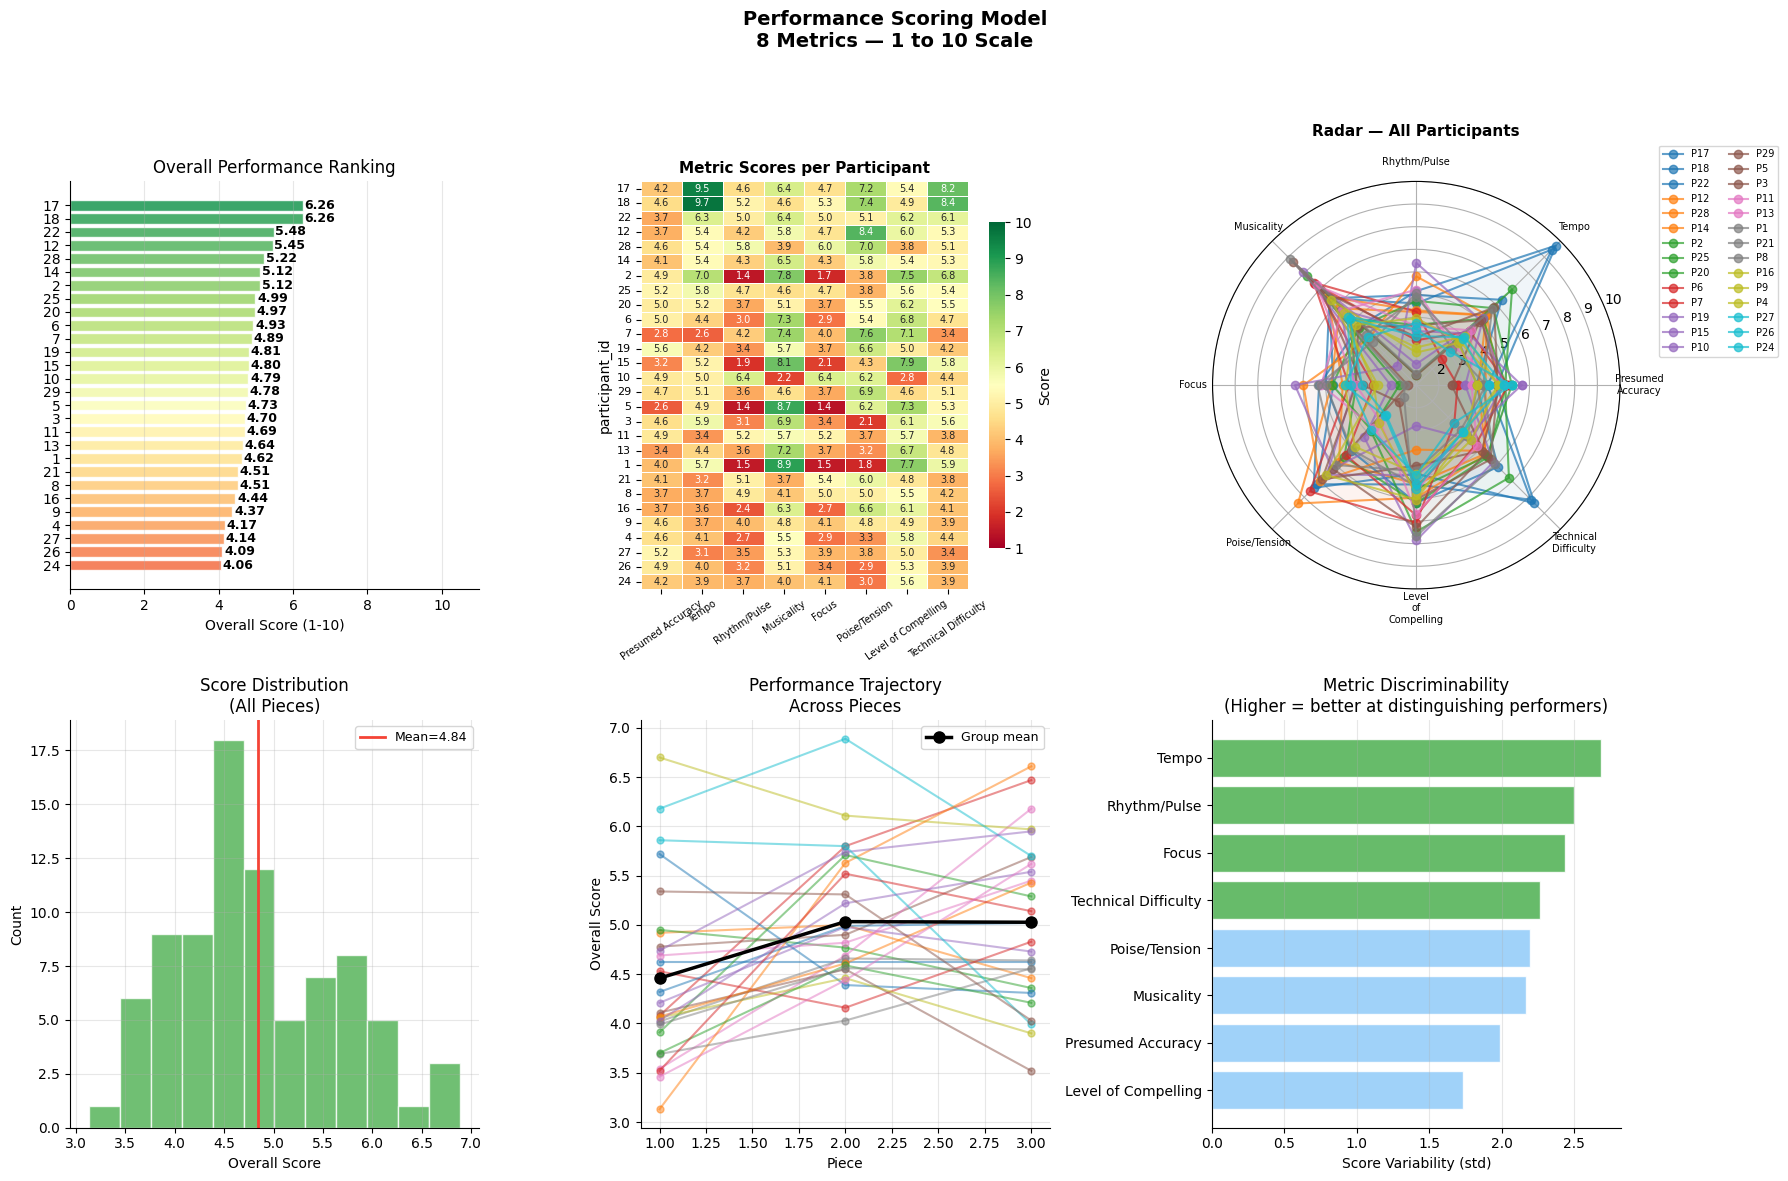

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/performance_scores.png

[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results
[DONE]


In [1]:
"""
Performance Scoring Model
Scores each participant's audio recording based on:
- Presumed Accuracy (1-10)
- Tempo (1=slow, 10=fast)
- Rhythm/Pulse (1-10)
- Musicality (1-10)
- Focus (1-10)
- Poise/Tension (1-10)
- Level of Compelling (1-10)
- Level of Technical Difficulty (1-10)

Uses audio features from MP3 files to estimate each metric.
Output: performance_scores.csv, performance_scores.png
"""

import os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
AUDIO_DIR    = '/Users/manognas/Downloads/2Inspire/audio'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
AUDIO_EXTS   = {'.mp3','.wav','.flac','.m4a'}
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── METRIC DEFINITIONS ────────────────────────────────────────────────────────
#
# Each metric maps to one or more audio features:
#
# 1. Presumed Accuracy    → pitch stability + chroma clarity
# 2. Tempo                → tempo_bpm (direct mapping)
# 3. Rhythm/Pulse         → tempo stability + beat regularity
# 4. Musicality           → chroma entropy + dynamic variation + expressiveness
# 5. Focus                → spectral flatness (inverse) + onset consistency
# 6. Poise/Tension        → RMS variation + spectral centroid stability
# 7. Level of Compelling  → dynamic range + mfcc variation + onset rate
# 8. Technical Difficulty → spectral complexity + onset density + tempo

# ── EXTRACT AUDIO FEATURES ───────────────────────────────────────────────────

try:
    import librosa
except ImportError:
    raise ImportError("pip install librosa")

print("="*55)
print("  Extracting audio features for performance scoring")
print("="*55)

def extract_features(filepath):
    y, sr    = librosa.load(filepath, sr=None, mono=True)
    duration = librosa.get_duration(y=y, sr=sr)

    # Tempo & rhythm
    tempo, beats   = librosa.beat.beat_track(y=y, sr=sr)
    tempo_val      = float(np.atleast_1d(tempo)[0])
    beat_times     = librosa.frames_to_time(beats, sr=sr)
    beat_intervals = np.diff(beat_times)
    tempo_stab     = float(1 - np.std(beat_intervals)/(np.mean(beat_intervals)+1e-9)) \
                     if len(beat_intervals)>1 else 0.5
    onset_frames   = librosa.onset.onset_detect(y=y, sr=sr)
    onset_rate     = len(onset_frames)/duration
    onset_times    = librosa.frames_to_time(onset_frames, sr=sr)
    onset_intervals= np.diff(onset_times)
    onset_consist  = float(1 - np.std(onset_intervals)/(np.mean(onset_intervals)+1e-9)) \
                     if len(onset_intervals)>1 else 0.5

    # Pitch & accuracy
    f0, voiced, _  = librosa.pyin(y, fmin=librosa.note_to_hz('C2'),
                                   fmax=librosa.note_to_hz('C7'))
    voiced_f0      = f0[voiced] if voiced.any() else np.array([440.0])
    pitch_stab     = float(1 - np.std(voiced_f0)/(np.mean(voiced_f0)+1e-9))
    voiced_ratio   = float(voiced.mean())

    # Chroma
    chroma         = librosa.feature.chroma_cqt(y=y, sr=sr)
    ch_n           = chroma/(chroma.sum(axis=0,keepdims=True)+1e-9)
    chroma_entropy = float(-np.sum(ch_n*np.log(ch_n+1e-9),axis=0).mean())
    chroma_clarity = float(np.mean(np.max(chroma, axis=0)))

    # Dynamics
    rms            = librosa.feature.rms(y=y)[0]
    mean_rms       = float(np.mean(rms))
    rms_var        = float(np.std(rms))
    dynamic_range  = float(np.ptp(rms))

    # Spectral
    spec_centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spec_flatness  = librosa.feature.spectral_flatness(y=y)[0]
    spec_rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    centroid_stab  = float(1 - np.std(spec_centroid)/(np.mean(spec_centroid)+1e-9))
    mean_flatness  = float(np.mean(spec_flatness))

    # MFCC variation (expressiveness)
    mfcc           = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_var       = float(np.mean(np.std(mfcc, axis=1)))

    # Harmonic/percussive ratio (tonal clarity)
    y_harm, y_perc = librosa.effects.hpss(y)
    harm_ratio     = float(np.mean(librosa.feature.rms(y=y_harm)[0]) /
                           (np.mean(librosa.feature.rms(y=y_perc)[0])+1e-9))

    return {
        'tempo_bpm':      tempo_val,
        'tempo_stability':tempo_stab,
        'onset_rate':     onset_rate,
        'onset_consist':  onset_consist,
        'pitch_stability':pitch_stab,
        'voiced_ratio':   voiced_ratio,
        'chroma_entropy': chroma_entropy,
        'chroma_clarity': chroma_clarity,
        'mean_rms':       mean_rms,
        'rms_variation':  rms_var,
        'dynamic_range':  dynamic_range,
        'centroid_stab':  centroid_stab,
        'spectral_flat':  mean_flatness,
        'mfcc_variation': mfcc_var,
        'harm_ratio':     min(harm_ratio, 10),
        'duration_s':     duration,
    }

# ── SCORE METRICS (1-10) ──────────────────────────────────────────────────────

def compute_scores(feat):
    """
    Map audio features to 1-10 performance metrics.
    Each metric is a weighted combination of relevant features.
    Higher score = better performance on that dimension.
    """
    scores = {}

    # 1. Presumed Accuracy (pitch stability + chroma clarity + harmonic ratio)
    scores['Presumed Accuracy'] = (
        0.4 * feat['pitch_stability'] +
        0.3 * feat['chroma_clarity'] +
        0.3 * min(feat['harm_ratio']/5, 1.0)
    )

    # 2. Tempo (direct BPM mapping — normalised to typical range 60-180)
    scores['Tempo'] = np.clip((feat['tempo_bpm'] - 60) / (180 - 60), 0, 1)

    # 3. Rhythm/Pulse (tempo stability + onset consistency)
    scores['Rhythm/Pulse'] = (
        0.5 * max(feat['tempo_stability'], 0) +
        0.5 * max(feat['onset_consist'], 0)
    )

    # 4. Musicality (chroma entropy + dynamic range + mfcc variation)
    # Higher entropy + more dynamics + more expression = more musical
    scores['Musicality'] = (
        0.35 * min(feat['chroma_entropy']/2.5, 1.0) +
        0.35 * min(feat['dynamic_range']*20, 1.0) +
        0.30 * min(feat['mfcc_variation']/20, 1.0)
    )

    # 5. Focus (inverse of spectral flatness + onset consistency)
    # Lower flatness = more tonal focus, higher onset consistency = more focused
    scores['Focus'] = (
        0.5 * (1 - min(feat['spectral_flat']*100, 1.0)) +
        0.5 * max(feat['onset_consist'], 0)
    )

    # 6. Poise/Tension (centroid stability + inverse RMS variation)
    # Stable timbre + controlled dynamics = poised performance
    scores['Poise/Tension'] = (
        0.5 * max(feat['centroid_stab'], 0) +
        0.5 * (1 - min(feat['rms_variation']*20, 1.0))
    )

    # 7. Level of Compelling (dynamic range + mfcc variation + onset rate)
    # More variation, expression, density = more compelling
    scores['Level of Compelling'] = (
        0.35 * min(feat['dynamic_range']*20, 1.0) +
        0.35 * min(feat['mfcc_variation']/20, 1.0) +
        0.30 * min(feat['onset_rate']/10, 1.0)
    )

    # 8. Technical Difficulty (onset density + tempo + chroma complexity)
    # Faster tempo, more notes, more harmonic complexity = more difficult
    scores['Technical Difficulty'] = (
        0.35 * min(feat['onset_rate']/10, 1.0) +
        0.35 * np.clip((feat['tempo_bpm']-60)/(180-60), 0, 1) +
        0.30 * min(feat['chroma_entropy']/2.5, 1.0)
    )

    # Convert 0-1 to 1-10
    return {k: round(v*9 + 1, 2) for k,v in scores.items()}

# ── PROCESS ALL AUDIO FILES ───────────────────────────────────────────────────

rows = []
for fname in sorted(os.listdir(AUDIO_DIR)):
    if os.path.splitext(fname)[1].lower() not in AUDIO_EXTS: continue
    m = re.match(r'P(\d+)_video(\d+)', fname)
    if not m: continue
    pid, piece = str(m.group(1)), int(m.group(2))

    try:
        feats  = extract_features(os.path.join(AUDIO_DIR, fname))
        scores = compute_scores(feats)
        # Overall score — weighted average
        weights = {'Presumed Accuracy':0.20, 'Tempo':0.10, 'Rhythm/Pulse':0.15,
                   'Musicality':0.15, 'Focus':0.15, 'Poise/Tension':0.10,
                   'Level of Compelling':0.10, 'Technical Difficulty':0.05}
        overall = sum(scores[k]*weights[k] for k in weights)
        row = {'participant_id':pid, 'piece':piece, 'filename':fname,
               'overall_score':round(overall,2), **scores, **feats}
        rows.append(row)
        print(f"  [OK] P{pid} piece={piece} overall={overall:.2f} "
              f"accuracy={scores['Presumed Accuracy']:.1f} "
              f"musicality={scores['Musicality']:.1f}")
    except Exception as e:
        print(f"  [SKIP] {fname}: {e}")

score_df = pd.DataFrame(rows)
metrics  = ['Presumed Accuracy','Tempo','Rhythm/Pulse','Musicality',
            'Focus','Poise/Tension','Level of Compelling','Technical Difficulty']

# ── SCALE TO 1-10 PER METRIC ──────────────────────────────────────────────────
# Rescale so best performer = 10, worst = 1 within each metric

scaler = MinMaxScaler(feature_range=(1,10))
score_df[metrics] = scaler.fit_transform(score_df[metrics])
score_df['overall_score'] = score_df[metrics].mean(axis=1).round(2)

print(f"\n[INFO] Scored {len(score_df)} recordings | {score_df['participant_id'].nunique()} participants")

# ── PARTICIPANT-LEVEL SUMMARY ──────────────────────────────────────────────────

part_scores = score_df.groupby('participant_id')[metrics+['overall_score']].mean().reset_index()
part_scores = part_scores.sort_values('overall_score', ascending=False).reset_index(drop=True)
part_scores['rank'] = part_scores.index + 1

print(f"\n{'='*55}\n  PERFORMANCE RANKINGS\n{'='*55}")
print(part_scores[['rank','participant_id','overall_score']+metrics[:4]].to_string(index=False))

# ── PLOTS ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle("Performance Scoring Model\n8 Metrics — 1 to 10 Scale",
             fontsize=14,fontweight='bold')

PALETTE = plt.cm.RdYlGn(np.linspace(0.2,0.9,len(part_scores)))

# 1. Overall leaderboard
ax = axes[0,0]
bars = ax.barh(part_scores['participant_id'][::-1],
               part_scores['overall_score'][::-1],
               color=PALETTE, alpha=0.85, edgecolor='white')
for bar,val in zip(bars,part_scores['overall_score'][::-1]):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold')
ax.set(xlabel='Overall Score (1-10)', title='Overall Performance Ranking')
ax.set_xlim(0,11); ax.grid(axis='x',alpha=0.3); _style(ax)

# 2. Heatmap of all metrics
ax = axes[0,1]
hm = part_scores.set_index('participant_id')[metrics]
sns.heatmap(hm, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=1, vmax=10, linewidths=0.5, linecolor='white',
            annot_kws={'size':7}, cbar_kws={'label':'Score','shrink':0.8})
ax.set_title("Metric Scores per Participant", fontsize=11, fontweight='bold')
ax.tick_params(axis='x',rotation=35,labelsize=7)
ax.tick_params(axis='y',rotation=0,labelsize=8)

# 3. Radar chart
ax = axes[0,2]; ax.remove()
ax = fig.add_subplot(2,3,3,polar=True)
angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False).tolist()
angles += angles[:1]
ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.replace(' ','\n') for m in metrics],size=7)
ax.set_ylim(1,10)
colors = plt.cm.tab10(np.linspace(0,1,len(part_scores)))
for i,(_,row) in enumerate(part_scores.iterrows()):
    vals = row[metrics].tolist() + [row[metrics[0]]]
    ax.plot(angles,vals,'o-',lw=1.5,color=colors[i],
            label=f"P{row['participant_id']}",alpha=0.7)
    ax.fill(angles,vals,alpha=0.03,color=colors[i])
ax.set_title("Radar — All Participants",fontsize=11,fontweight='bold',pad=15)
ax.legend(loc='upper right',bbox_to_anchor=(1.4,1.1),fontsize=7,ncol=2)

# 4. Score distribution
ax = axes[1,0]
ax.hist(score_df['overall_score'],bins=12,color='#4CAF50',alpha=0.8,edgecolor='white')
ax.axvline(score_df['overall_score'].mean(),color='#F44336',lw=2,
           label=f"Mean={score_df['overall_score'].mean():.2f}")
ax.set(xlabel='Overall Score',ylabel='Count',title='Score Distribution\n(All Pieces)')
ax.legend(fontsize=9); ax.grid(alpha=0.3); _style(ax)

# 5. Score by piece
ax = axes[1,1]
for pid,grp in score_df.groupby('participant_id'):
    grp = grp.sort_values('piece')
    ax.plot(grp['piece'],grp['overall_score'],'o-',alpha=0.5,lw=1.5,ms=5)
mean_piece = score_df.groupby('piece')['overall_score'].mean()
ax.plot(mean_piece.index,mean_piece.values,'k-o',lw=2.5,ms=8,label='Group mean')
ax.set(xlabel='Piece',ylabel='Overall Score',
       title='Performance Trajectory\nAcross Pieces')
ax.legend(fontsize=9); ax.grid(alpha=0.3); _style(ax)

# 6. Metric importance (variance)
ax = axes[1,2]
metric_var = score_df[metrics].std().sort_values(ascending=True)
ax.barh(metric_var.index,metric_var.values,
        color=['#4CAF50' if v>metric_var.median() else '#90CAF9'
               for v in metric_var.values],
        alpha=0.85,edgecolor='white')
ax.set(xlabel='Score Variability (std)',
       title='Metric Discriminability\n(Higher = better at distinguishing performers)')
ax.grid(axis='x',alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.94])
path = os.path.join(OUTPUT_DIR,'performance_scores.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── SAVE ──────────────────────────────────────────────────────────────────────

score_df.to_csv(os.path.join(OUTPUT_DIR,'performance_scores.csv'),index=False)
part_scores.to_csv(os.path.join(OUTPUT_DIR,'performance_scores_participant.csv'),index=False)

with open(os.path.join(OUTPUT_DIR,'performance_report.txt'),'w') as f:
    f.write("PERFORMANCE SCORING REPORT\n"+"="*45+"\n\n")
    f.write("Metrics (1-10 scale):\n")
    f.write("  1. Presumed Accuracy  — pitch stability + chroma clarity\n")
    f.write("  2. Tempo              — BPM (1=slow, 10=fast)\n")
    f.write("  3. Rhythm/Pulse       — tempo stability + onset consistency\n")
    f.write("  4. Musicality         — harmonic variety + dynamics + expression\n")
    f.write("  5. Focus              — tonal clarity + onset consistency\n")
    f.write("  6. Poise/Tension      — timbre stability + dynamic control\n")
    f.write("  7. Level of Compelling— dynamic range + expression + note density\n")
    f.write("  8. Technical Difficulty— tempo + note density + harmonic complexity\n\n")
    f.write("RANKINGS\n"+"-"*30+"\n")
    f.write(part_scores[['rank','participant_id','overall_score']].to_string(index=False))
print(f"\n[SAVED] {OUTPUT_DIR}\n[DONE]")

[INFO] 10 participants matched
[INFO] RSA=['mean_p2t', 'rmssd', 'pnn50', 'sd1_sd2']
[INFO] Performance metrics=['Presumed Accuracy', 'Tempo', 'Rhythm/Pulse', 'Musicality', 'Focus', 'Poise/Tension', 'Level of Compelling', 'Technical Difficulty']

  MODEL A: Music → Vagal Tone → Performance Quality
  a  (Music→Vagal):        +0.3251
  b  (Vagal→Performance):  -0.3247
  c  (total Music→Perf):   +0.4236
  c' (direct Music→Perf):  +0.5292
  ab (indirect):           -0.1056
  CI: [-0.5656, 0.5307]
  ns  prop=24.9%
  Bayesian P(ab<0) = 63.3%

  MODEL B: Music → Vagal → Each Performance Metric
  Presumed Accuracy        : ab=-0.1557 ns P(ab<0)=83.7% prop=53.8%
  Tempo                    : ab=-0.1027 ns P(ab<0)=66.8% prop=37.1%
  Rhythm/Pulse             : ab=-0.1106 ns P(ab<0)=82.3% prop=23.2%
  Musicality               : ab=+0.0286 ns P(ab<0)=23.9% prop=3.6%
  Focus                    : ab=-0.1037 ns P(ab<0)=81.3% prop=20.9%
  Poise/Tension            : ab=+0.0514 ns P(ab<0)=26.4% prop=10.5%


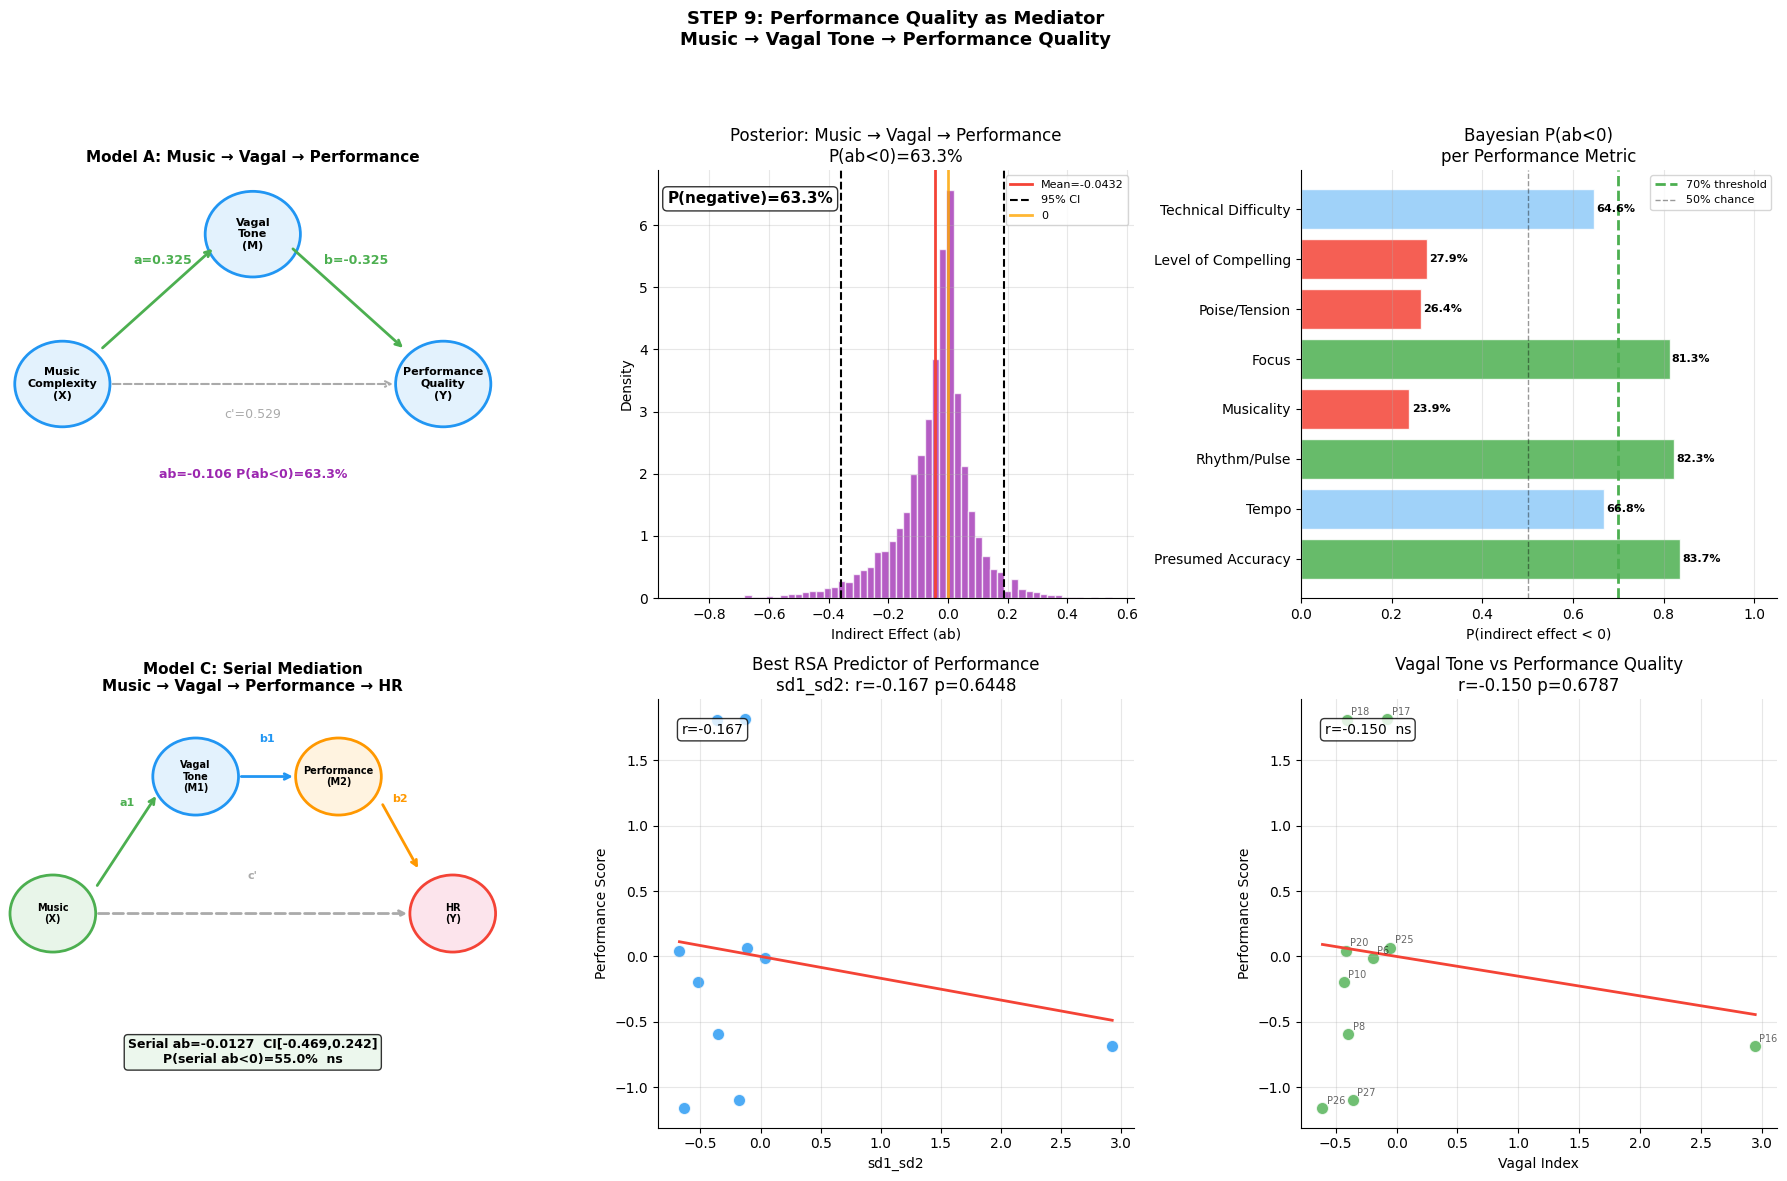

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/step9_performance_mediation.png

[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results
[DONE]


In [2]:
"""
STEP 9 — Performance Quality as Mediator/Outcome
Tests: Music Complexity → Vagal Tone → Performance Quality
Also: Serial Mediation Music → Vagal → Performance → HR
Output: step9_performance_mediation.png, step9_report.txt
"""

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
RSA_FEATS    = ['mean_p2t','rmssd','pnn50','sd1_sd2']
METRICS      = ['Presumed Accuracy','Tempo','Rhythm/Pulse','Musicality',
                'Focus','Poise/Tension','Level of Compelling','Technical Difficulty']
N_BOOT       = 1000
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── LOAD DATA ──────────────────────────────────────────────────────────────────

rsa_piece   = pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_clean_computed.csv'))
audio_piece = pd.read_csv(os.path.join(OUTPUT_DIR,'chroma_summary_clean.csv'))
perf_piece  = pd.read_csv(os.path.join(OUTPUT_DIR,'performance_scores.csv'))
perf_part   = pd.read_csv(os.path.join(OUTPUT_DIR,'performance_scores_participant.csv'))

for d in [rsa_piece, audio_piece, perf_piece, perf_part]:
    for col in d.columns:
        if 'participant' in col.lower() or col == 'p_number':
            d[col] = d[col].astype(str).str.strip()

rsa_feats    = [f for f in RSA_FEATS if f in rsa_piece.columns]
avail_metrics = [m for m in METRICS if m in perf_part.columns]

# Participant-level aggregates
rsa_part    = rsa_piece.groupby('p_number')[rsa_feats+(['mean_hr'] if 'mean_hr' in rsa_piece.columns else [])].mean().reset_index()
audio_part  = audio_piece.groupby('participant_id')[['chroma_entropy']].mean().reset_index()\
                         .rename(columns={'participant_id':'p_number'})
perf_part   = perf_part.rename(columns={'participant_id':'p_number'}) \
              if 'participant_id' in perf_part.columns else perf_part

df = rsa_part\
    .merge(audio_part, on='p_number', how='inner')\
    .merge(perf_part[['p_number','overall_score']+avail_metrics], on='p_number', how='inner')\
    .dropna(subset=rsa_feats)

# Standardise
sc   = StandardScaler()
cols = rsa_feats + ['chroma_entropy','overall_score'] + \
       (['mean_hr'] if 'mean_hr' in df.columns else [])
df[cols] = sc.fit_transform(df[cols])
df['vagal_index'] = df[[f for f in ['mean_p2t','rmssd','pnn50'] if f in df.columns]].mean(axis=1)

# Standardise individual metrics
for m in avail_metrics:
    df[m] = (df[m]-df[m].mean())/(df[m].std()+1e-9)

print(f"[INFO] {len(df)} participants matched")
print(f"[INFO] RSA={rsa_feats}")
print(f"[INFO] Performance metrics={avail_metrics}")

X  = df['chroma_entropy'].values
M  = df['vagal_index'].values
P  = df['overall_score'].values
Y  = df['mean_hr'].values if 'mean_hr' in df.columns else P
Y_col = 'mean_hr' if 'mean_hr' in df.columns else 'overall_score'

# ── MEDIATION FUNCTIONS ────────────────────────────────────────────────────────

def reg(x, y):
    b = np.linalg.lstsq(np.column_stack([np.ones(len(x)),x]),y,rcond=None)[0]
    return b[1], b[0]

def med(x, m, y, n=N_BOOT):
    a,_ = reg(x,m); c,_ = reg(x,y)
    bv  = np.linalg.lstsq(np.column_stack([np.ones(len(x)),x,m]),y,rcond=None)[0]
    cp,b = bv[1],bv[2]; ab=a*b
    boot=[]; idx=np.arange(len(x))
    for _ in range(n):
        s=np.random.choice(idx,len(idx),replace=True)
        a_,_=reg(x[s],m[s])
        bvb=np.linalg.lstsq(np.column_stack([np.ones(len(s)),x[s],m[s]]),y[s],rcond=None)[0]
        boot.append(a_*bvb[2])
    boot=np.array(boot); ci=np.percentile(boot,[2.5,97.5])
    return {'a':a,'b':b,'c':c,'cp':cp,'ab':ab,'ci_lo':ci[0],'ci_hi':ci[1],
            'sig':not(ci[0]<=0<=ci[1]),'prop':abs(ab/c)*100 if abs(c)>1e-6 else np.nan,
            'p_neg':np.mean(boot<0),'boot':boot}

def bayes_reg(x, y, n_samples=5000):
    n    = len(x)
    Xm   = np.column_stack([np.ones(n),x])
    b    = np.linalg.lstsq(Xm,y,rcond=None)[0]
    res  = y - Xm@b
    s2   = np.var(res)
    prior_cov = np.eye(2)
    like_cov  = s2 * np.linalg.inv(Xm.T@Xm)
    post_cov  = np.linalg.inv(np.linalg.inv(prior_cov)+np.linalg.inv(like_cov))
    post_mean = post_cov @ (np.linalg.inv(like_cov)@b)
    samples   = np.random.multivariate_normal(post_mean, post_cov, n_samples)
    return samples[:,1]

# ── MODEL A: Music → Vagal → Performance ──────────────────────────────────────

print(f"\n{'='*55}")
print(f"  MODEL A: Music → Vagal Tone → Performance Quality")
print(f"{'='*55}")

rA = med(X, M, P)
print(f"  a  (Music→Vagal):        {rA['a']:+.4f}")
print(f"  b  (Vagal→Performance):  {rA['b']:+.4f}")
print(f"  c  (total Music→Perf):   {rA['c']:+.4f}")
print(f"  c' (direct Music→Perf):  {rA['cp']:+.4f}")
print(f"  ab (indirect):           {rA['ab']:+.4f}")
print(f"  CI: [{rA['ci_lo']:.4f}, {rA['ci_hi']:.4f}]")
print(f"  {'SIGNIFICANT *' if rA['sig'] else 'ns'}  prop={rA['prop']:.1f}%")

# Bayesian
a_samp = bayes_reg(X, M)
b_samp = bayes_reg(M, P)
ab_samp_A = a_samp * b_samp
p_neg_A = np.mean(ab_samp_A < 0)
print(f"  Bayesian P(ab<0) = {p_neg_A:.1%}")

# ── MODEL B: Per-Metric Mediation ─────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"  MODEL B: Music → Vagal → Each Performance Metric")
print(f"{'='*55}")

metric_results = {}
for metric in avail_metrics:
    if metric not in df.columns: continue
    Pm = df[metric].values
    r  = med(X, M, Pm)
    a_s = bayes_reg(X, M); b_s = bayes_reg(M, Pm)
    ab_s = a_s * b_s
    metric_results[metric] = {**r, 'p_neg_bayes': np.mean(ab_s<0), 'ab_boot_b': ab_s}
    print(f"  {metric:<25}: ab={r['ab']:+.4f} "
          f"{'*' if r['sig'] else 'ns'} "
          f"P(ab<0)={np.mean(ab_s<0):.1%} "
          f"prop={r['prop']:.1f}%")

# ── MODEL C: SERIAL MEDIATION Music → Vagal → Performance → HR ───────────────

print(f"\n{'='*55}")
print(f"  MODEL C: Serial Mediation")
print(f"  Music → Vagal → Performance → HR")
print(f"{'='*55}")

# Path a: X → M (vagal)
a1, _ = reg(X, M)

# Path b1: M → P (vagal → performance) controlling X
bv1 = np.linalg.lstsq(np.column_stack([np.ones(len(X)),X,M]),P,rcond=None)[0]
b1  = bv1[2]

# Path b2: P → Y (performance → HR) controlling X and M
bv2 = np.linalg.lstsq(np.column_stack([np.ones(len(X)),X,M,P]),Y,rcond=None)[0]
b2  = bv2[3]

# Serial indirect effect
serial_ab = a1 * b1 * b2

# Bootstrap serial indirect
serial_boot = []
idx = np.arange(len(X))
for _ in range(N_BOOT):
    s    = np.random.choice(idx,len(idx),replace=True)
    a1_b,_ = reg(X[s],M[s])
    bv1_b  = np.linalg.lstsq(np.column_stack([np.ones(len(s)),X[s],M[s]]),P[s],rcond=None)[0]
    bv2_b  = np.linalg.lstsq(np.column_stack([np.ones(len(s)),X[s],M[s],P[s]]),Y[s],rcond=None)[0]
    serial_boot.append(a1_b * bv1_b[2] * bv2_b[3])

serial_boot = np.array(serial_boot)
serial_ci   = np.percentile(serial_boot,[2.5,97.5])
serial_sig  = not(serial_ci[0]<=0<=serial_ci[1])
serial_p_neg = np.mean(serial_boot<0)

print(f"  a1  (Music→Vagal):       {a1:+.4f}")
print(f"  b1  (Vagal→Performance): {b1:+.4f}")
print(f"  b2  (Performance→HR):    {b2:+.4f}")
print(f"  a1×b1×b2 (serial ab):    {serial_ab:+.4f}")
print(f"  CI: [{serial_ci[0]:.4f}, {serial_ci[1]:.4f}]")
print(f"  {'SIGNIFICANT *' if serial_sig else 'ns'}")
print(f"  Bayesian P(serial ab<0) = {serial_p_neg:.1%}")

# ── RSA FEATURES → PERFORMANCE ────────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"  RSA FEATURES → PERFORMANCE CORRELATIONS")
print(f"{'='*55}")
corr_rows = []
for feat in rsa_feats:
    r,p = stats.pearsonr(df[feat].values, P)
    corr_rows.append({'rsa_feat':feat,'r':round(r,3),'p':round(p,4),'sig':p<0.05})
    print(f"  {feat:<15}: r={r:+.3f} p={p:.4f} {'*' if p<0.05 else ''}")
corr_df = pd.DataFrame(corr_rows)

# ── PLOTS ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle("STEP 9: Performance Quality as Mediator\n"
             "Music → Vagal Tone → Performance Quality",
             fontsize=13,fontweight='bold')

# 1. Model A path diagram
ax = axes[0,0]; ax.axis('off')
ax.set_title("Model A: Music → Vagal → Performance",fontsize=11,fontweight='bold')
nodes = [(0.1,0.5,'Music\nComplexity\n(X)'),(0.5,0.85,'Vagal\nTone\n(M)'),
         (0.9,0.5,'Performance\nQuality\n(Y)')]
for (x,y,t) in nodes:
    ax.add_patch(plt.Circle((x,y),0.1,color='#E3F2FD',ec='#2196F3',lw=2,
                             transform=ax.transAxes,clip_on=False))
    ax.text(x,y,t,ha='center',va='center',fontsize=8,fontweight='bold',transform=ax.transAxes)
ca = '#4CAF50' if abs(rA['a'])>0.1 else '#aaa'
cb = '#4CAF50' if abs(rA['b'])>0.1 else '#aaa'
cc = '#F44336' if rA['sig'] else '#aaa'
ax.annotate('',xy=(0.42,0.82),xytext=(0.18,0.58),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=ca,lw=2))
ax.annotate('',xy=(0.82,0.58),xytext=(0.58,0.82),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=cb,lw=2))
ax.annotate('',xy=(0.8,0.5),xytext=(0.2,0.5),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=cc,lw=1.5,
                                                        linestyle='dashed'))
ax.text(0.25,0.78,f"a={rA['a']:.3f}",fontsize=9,color=ca,fontweight='bold',
        transform=ax.transAxes)
ax.text(0.65,0.78,f"b={rA['b']:.3f}",fontsize=9,color=cb,fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5,0.42,f"c'={rA['cp']:.3f}",fontsize=9,color=cc,transform=ax.transAxes,ha='center')
ax.text(0.5,0.28,f"ab={rA['ab']:.3f} P(ab<0)={p_neg_A:.1%}",
        fontsize=9,color='#9C27B0',fontweight='bold',transform=ax.transAxes,ha='center')

# 2. Posterior distribution Model A
ax = axes[0,1]
ax.hist(ab_samp_A,bins=60,color='#9C27B0',alpha=0.75,edgecolor='white',density=True)
ax.axvline(ab_samp_A.mean(),color='#F44336',lw=2,label=f"Mean={ab_samp_A.mean():.4f}")
ax.axvline(np.percentile(ab_samp_A,2.5),color='k',lw=1.5,ls='--',label="95% CI")
ax.axvline(np.percentile(ab_samp_A,97.5),color='k',lw=1.5,ls='--')
ax.axvline(0,color='orange',lw=2,alpha=0.8,label='0')
ax.set(xlabel='Indirect Effect (ab)',ylabel='Density',
       title=f'Posterior: Music → Vagal → Performance\nP(ab<0)={p_neg_A:.1%}')
ax.text(0.02,0.95,f'P(negative)={p_neg_A:.1%}',transform=ax.transAxes,
        fontsize=11,va='top',fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 3. Per-metric Bayesian probabilities
ax = axes[0,2]
if metric_results:
    mets  = list(metric_results.keys())
    p_negs= [metric_results[m]['p_neg_bayes'] for m in mets]
    colors= ['#4CAF50' if p>0.7 else '#90CAF9' if p>0.5 else '#F44336' for p in p_negs]
    ax.barh(mets,p_negs,color=colors,alpha=0.85,edgecolor='white')
    ax.axvline(0.7,color='#4CAF50',lw=2,ls='--',label='70% threshold')
    ax.axvline(0.5,color='k',lw=1,ls='--',alpha=0.4,label='50% chance')
    for i,(v,m) in enumerate(zip(p_negs,mets)):
        ax.text(v+0.005,i,f'{v:.1%}',va='center',fontsize=8,fontweight='bold')
    ax.set(xlabel='P(indirect effect < 0)',xlim=[0,1.05],
           title='Bayesian P(ab<0)\nper Performance Metric')
    ax.legend(fontsize=8); ax.grid(axis='x',alpha=0.3); _style(ax)

# 4. Serial mediation diagram
ax = axes[1,0]; ax.axis('off')
ax.set_title("Model C: Serial Mediation\nMusic → Vagal → Performance → HR",
             fontsize=11,fontweight='bold')
nodes4 = [(0.08,0.5,'Music\n(X)'),(0.38,0.82,'Vagal\nTone\n(M1)'),
          (0.68,0.82,'Performance\n(M2)'),(0.92,0.5,f'HR\n(Y)')]
cols4  = ['#E8F5E9','#E3F2FD','#FFF3E0','#FCE4EC']
ecs4   = ['#4CAF50','#2196F3','#FF9800','#F44336']
for (x,y,t),c,e in zip(nodes4,cols4,ecs4):
    ax.add_patch(plt.Circle((x,y),0.09,color=c,ec=e,lw=2,
                             transform=ax.transAxes,clip_on=False))
    ax.text(x,y,t,ha='center',va='center',fontsize=7,fontweight='bold',transform=ax.transAxes)
arrows4 = [((0.17,0.56),(0.30,0.78),'a1','#4CAF50'),
           ((0.47,0.82),(0.59,0.82),'b1','#2196F3'),
           ((0.77,0.76),(0.85,0.60),'b2','#FF9800'),
           ((0.17,0.5),(0.83,0.5),"c'",'#aaa')]
for (s,e,lbl,col) in arrows4:
    ax.annotate('',xy=e,xytext=s,xycoords='axes fraction',textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->',color=col,lw=2,
                                linestyle='dashed' if lbl=="c'" else 'solid'))
    ax.text((s[0]+e[0])/2,(s[1]+e[1])/2+0.08,lbl,ha='center',fontsize=8,
            transform=ax.transAxes,color=col,fontweight='bold')
ax.text(0.5,0.15,
        f"Serial ab={serial_ab:.4f}  CI[{serial_ci[0]:.3f},{serial_ci[1]:.3f}]\n"
        f"P(serial ab<0)={serial_p_neg:.1%}  {'SIGNIFICANT *' if serial_sig else 'ns'}",
        ha='center',fontsize=9,transform=ax.transAxes,fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='#E8F5E9',alpha=0.8))

# 5. RSA features → Performance scatter
ax = axes[1,1]
best_feat = corr_df.loc[corr_df['r'].abs().idxmax(),'rsa_feat']
x_plot = df[best_feat].values
ax.scatter(x_plot,P,color='#2196F3',s=80,alpha=0.8,edgecolors='white')
m_r,b_r = reg(x_plot,P)
xl = np.linspace(x_plot.min(),x_plot.max(),50)
ax.plot(xl,m_r*xl+b_r,color='#F44336',lw=2)
rv,pv = stats.pearsonr(x_plot,P)
ax.set(xlabel=best_feat,ylabel='Performance Score',
       title=f'Best RSA Predictor of Performance\n{best_feat}: r={rv:.3f} p={pv:.4f}')
ax.text(0.05,0.92,f'r={rv:.3f}{"  *" if pv<0.05 else ""}',
        transform=ax.transAxes,fontsize=10,
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.grid(alpha=0.3); _style(ax)

# 6. Performance vs vagal index scatter
ax = axes[1,2]
ax.scatter(M,P,color='#4CAF50',s=80,alpha=0.8,edgecolors='white')
m_v,b_v = reg(M,P)
xl = np.linspace(M.min(),M.max(),50)
ax.plot(xl,m_v*xl+b_v,color='#F44336',lw=2)
rv2,pv2 = stats.pearsonr(M,P)
for i,row in df.iterrows():
    ax.annotate(f"P{row['p_number']}",
                (row['vagal_index'],row['overall_score']),
                fontsize=7,alpha=0.6,
                xytext=(3,3),textcoords='offset points')
ax.set(xlabel='Vagal Index',ylabel='Performance Score',
       title=f'Vagal Tone vs Performance Quality\nr={rv2:.3f} p={pv2:.4f}')
ax.text(0.05,0.92,f'r={rv2:.3f}{"  *" if pv2<0.05 else "  ns"}',
        transform=ax.transAxes,fontsize=10,
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.grid(alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.94])
path = os.path.join(OUTPUT_DIR,'step9_performance_mediation.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── REPORT ─────────────────────────────────────────────────────────────────────

with open(os.path.join(OUTPUT_DIR,'step9_report.txt'),'w') as fout:
    fout.write("STEP 9 — PERFORMANCE QUALITY MEDIATION\n"+"="*50+"\n\n")
    fout.write(f"N={len(df)} participants\n\n")
    fout.write("MODEL A: Music → Vagal → Performance\n"+"-"*35+"\n")
    fout.write(f"a={rA['a']:+.4f}  b={rA['b']:+.4f}  ab={rA['ab']:+.4f}\n")
    fout.write(f"CI[{rA['ci_lo']:.4f},{rA['ci_hi']:.4f}] "
               f"{'*' if rA['sig'] else 'ns'} prop={rA['prop']:.1f}%\n")
    fout.write(f"Bayesian P(ab<0)={p_neg_A:.1%}\n\n")
    fout.write("MODEL B: Per-Metric Mediation\n"+"-"*35+"\n")
    for m,r in metric_results.items():
        fout.write(f"  {m:<25}: ab={r['ab']:+.4f} "
                   f"{'*' if r['sig'] else 'ns'} P(ab<0)={r['p_neg_bayes']:.1%}\n")
    fout.write(f"\nMODEL C: Serial Mediation\n"+"-"*35+"\n")
    fout.write(f"a1={a1:+.4f}  b1={b1:+.4f}  b2={b2:+.4f}\n")
    fout.write(f"Serial ab={serial_ab:+.4f} CI[{serial_ci[0]:.4f},{serial_ci[1]:.4f}]\n")
    fout.write(f"P(serial ab<0)={serial_p_neg:.1%} {'*' if serial_sig else 'ns'}\n\n")
    fout.write("RSA → Performance Correlations\n"+"-"*35+"\n")
    fout.write(corr_df.to_string(index=False))
print(f"\n[SAVED] {OUTPUT_DIR}\n[DONE]")

[INFO] Valid participants (good+excellent+marginal): 25

  STEP 2: Extracting audio features
  [OK] P10 piece=1 entropy=1.744 tempo=132.5 mode=minor
  [OK] P10 piece=2 entropy=1.848 tempo=110.0 mode=minor
  [OK] P10 piece=3 entropy=2.054 tempo=99.4 mode=major
  [OK] P11 piece=1 entropy=1.830 tempo=87.6 mode=minor
  [OK] P11 piece=2 entropy=1.994 tempo=110.0 mode=minor
  [OK] P11 piece=3 entropy=2.095 tempo=77.1 mode=major
  [OK] P12 piece=1 entropy=1.941 tempo=69.8 mode=minor
  [OK] P12 piece=2 entropy=1.994 tempo=152.0 mode=minor
  [OK] P12 piece=3 entropy=1.986 tempo=132.5 mode=minor
  [OK] P13 piece=1 entropy=1.844 tempo=84.7 mode=minor
  [OK] P13 piece=2 entropy=2.036 tempo=114.8 mode=minor
  [OK] P13 piece=3 entropy=2.194 tempo=117.5 mode=major
  [OK] P14 piece=1 entropy=1.956 tempo=79.5 mode=minor
  [OK] P14 piece=2 entropy=2.051 tempo=95.7 mode=minor
  [OK] P14 piece=3 entropy=2.145 tempo=224.7 mode=major
  [SKIP] P15 piece=1 — no valid RSA
  [SKIP] P15 piece=2 — no valid RSA
  

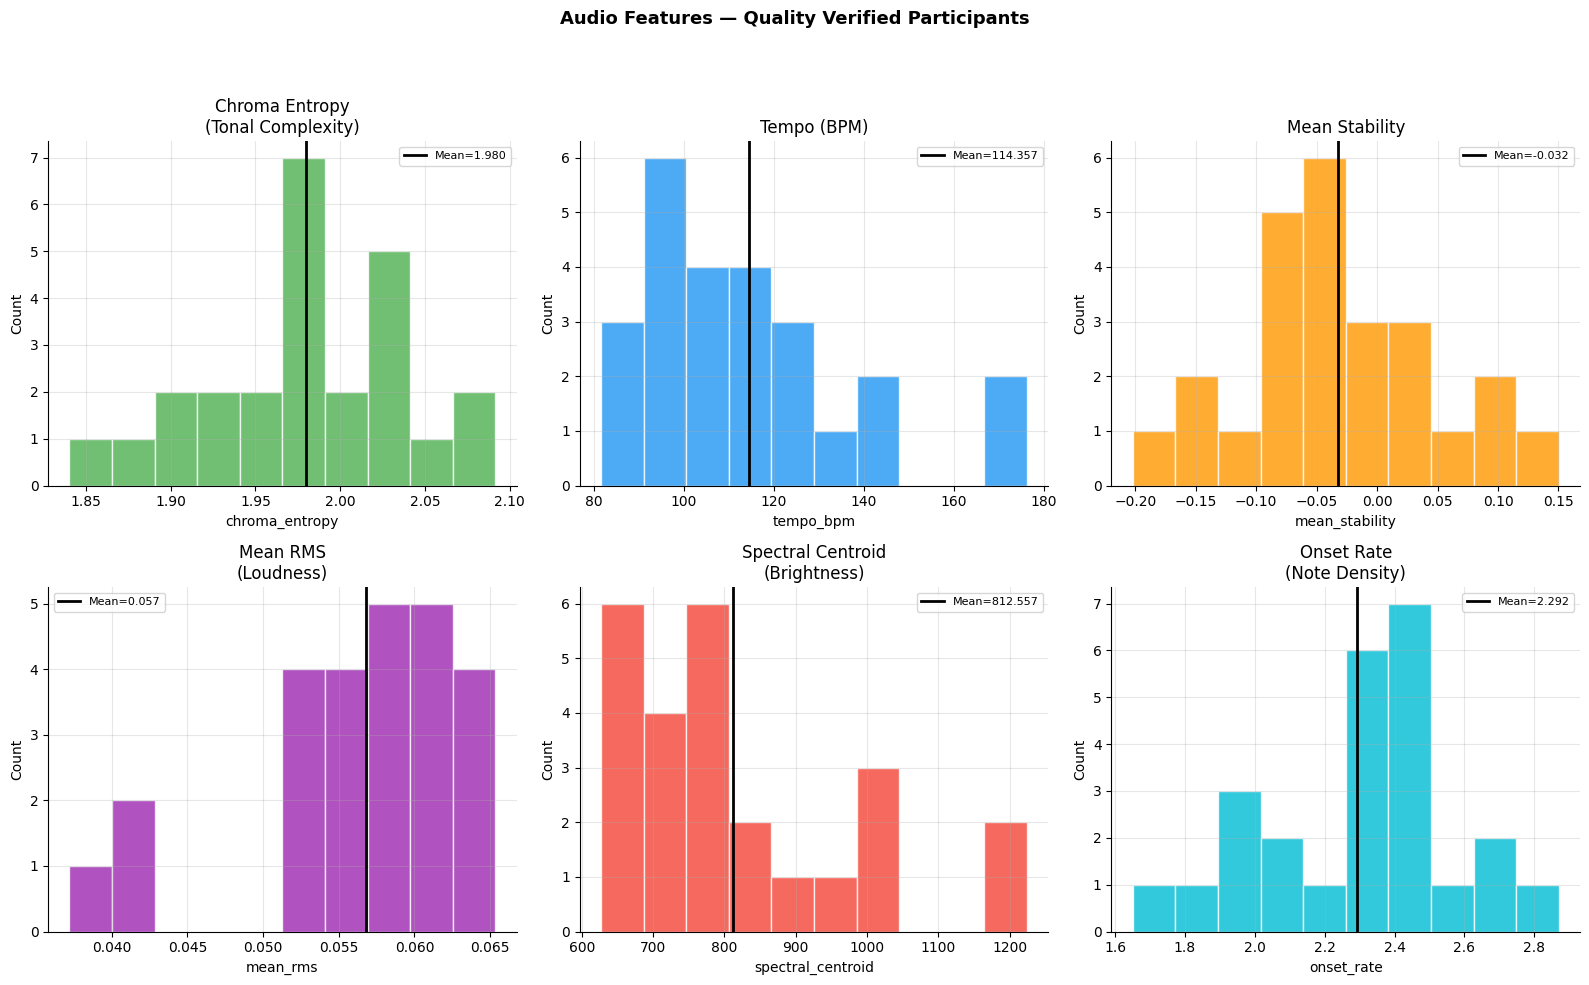

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/audio_features_clean.png
[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results
[DONE] Run step3_analysis.py next


In [2]:
"""
STEP 2 — Extract audio features from MP3 files
Only processes audio for participants with valid RSA (from Step 1)
Output: chroma_summary_clean.csv, audio_physio_summary_clean.csv
"""

import os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
AUDIO_DIR    = '/Users/manognas/Downloads/2Inspire/audio'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
AUDIO_EXTS   = {'.mp3','.wav','.flac','.m4a'}
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── LOAD VALID PARTICIPANTS FROM STEP 1 ───────────────────────────────────────

clean_path = os.path.join(OUTPUT_DIR,'rsa_raw_computed.csv')
if not os.path.exists(clean_path):
    raise FileNotFoundError("Run step1_rsa_from_raw.py first")

rsa_clean   = pd.read_csv(clean_path)
# Include good, excellent AND marginal participants
rsa_all_q   = pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_raw_computed.csv'))
valid_pids  = set(rsa_all_q[rsa_all_q['quality'].isin(['good','excellent','marginal'])]\
                  ['p_number'].astype(str).unique())
print(f"[INFO] Valid participants (good+excellent+marginal): {len(valid_pids)}")

# ── EXTRACT AUDIO FEATURES ────────────────────────────────────────────────────

try:
    import librosa
except ImportError:
    raise ImportError("pip install librosa")

print(f"\n{'='*55}\n  STEP 2: Extracting audio features\n{'='*55}")

audio_rows = []
for fname in sorted(os.listdir(AUDIO_DIR)):
    if os.path.splitext(fname)[1].lower() not in AUDIO_EXTS: continue
    m = re.match(r'P(\d+)_video(\d+)', fname)
    if not m: continue

    pid   = str(m.group(1))
    piece = int(m.group(2))

    # Only process if participant has valid RSA
    if pid not in valid_pids:
        print(f"  [SKIP] P{pid} piece={piece} — no valid RSA"); continue

    try:
        y, sr    = librosa.load(os.path.join(AUDIO_DIR,fname), sr=None, mono=True)
        duration = librosa.get_duration(y=y, sr=sr)

        # Chroma features
        chroma   = librosa.feature.chroma_cqt(y=y, sr=sr)
        ch_n     = chroma/(chroma.sum(axis=0,keepdims=True)+1e-9)
        entropy  = float(-np.sum(ch_n*np.log(ch_n+1e-9),axis=0).mean())
        stability= float(1-np.mean(np.std(chroma,axis=1)/(np.mean(chroma,axis=1)+1e-9)))
        dom_note = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']\
                   [np.argmax(chroma.mean(axis=1))]

        # Rhythm
        tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
        beat_t       = librosa.frames_to_time(beats, sr=sr)
        beat_int     = np.diff(beat_t)
        tempo_stab   = float(1-np.std(beat_int)/(np.mean(beat_int)+1e-9)) \
                       if len(beat_int)>1 else np.nan

        # Energy & tension
        rms      = float(np.mean(librosa.feature.rms(y=y)[0]))
        spec_c   = float(np.mean(librosa.feature.spectral_centroid(y=y,sr=sr)))
        onset_r  = len(librosa.onset.onset_detect(y=y,sr=sr))/duration

        # Mode
        major_t  = np.array([1,0,1,0,1,1,0,1,0,1,0,1],dtype=float)
        minor_t  = np.array([1,0,1,1,0,1,0,1,1,0,1,0],dtype=float)
        mc       = chroma.mean(axis=1)
        maj_c    = np.corrcoef(mc,np.roll(major_t,np.argmax(mc)))[0,1]
        min_c    = np.corrcoef(mc,np.roll(minor_t,np.argmax(mc)))[0,1]
        mode     = 'major' if maj_c>min_c else 'minor'

        audio_rows.append({
            'participant_id': pid, 'piece': piece, 'filename': fname,
            'duration_s':     round(duration,2),
            'chroma_entropy': round(entropy,4),
            'mean_stability': round(stability,4),
            'dominant_note':  dom_note, 'mode': mode,
            'tempo_bpm':      round(float(np.atleast_1d(tempo)[0]),2),
            'tempo_stability':round(tempo_stab,4) if not np.isnan(tempo_stab) else np.nan,
            'mean_rms':       round(rms,6),
            'spectral_centroid': round(spec_c,2),
            'onset_rate':     round(onset_r,4),
        })
        print(f"  [OK] P{pid} piece={piece} entropy={entropy:.3f} "
              f"tempo={float(np.atleast_1d(tempo)[0]):.1f} mode={mode}")

    except Exception as e:
        print(f"  [SKIP] {fname}: {e}")

audio_df = pd.DataFrame(audio_rows).sort_values(['participant_id','piece']).reset_index(drop=True)
print(f"\n[INFO] Audio features: {len(audio_df)} files | {audio_df['participant_id'].nunique()} participants")

# ── VERIFY MATCH WITH RSA ──────────────────────────────────────────────────────

rsa_pids   = set(rsa_clean['p_number'].astype(str).unique())
audio_pids = set(audio_df['participant_id'].astype(str).unique())
matched    = rsa_pids & audio_pids
missing_rsa   = audio_pids - rsa_pids
missing_audio = rsa_pids - audio_pids

print(f"\n{'='*55}\n  PARTICIPANT MATCH REPORT\n{'='*55}")
print(f"  RSA valid participants:   {len(rsa_pids)}")
print(f"  Audio participants:       {len(audio_pids)}")
print(f"  Matched (both):           {len(matched)}")
print(f"  Audio only (no RSA):      {sorted(missing_rsa)}")
print(f"  RSA only (no audio):      {sorted(missing_audio)}")
print(f"  Final analysis sample:    {len(matched)} participants")

# ── AGGREGATE PER PARTICIPANT ──────────────────────────────────────────────────

audio_cols = ['chroma_entropy','mean_stability','tempo_bpm','mean_rms',
              'spectral_centroid','onset_rate']
audio_part = audio_df.groupby('participant_id')[audio_cols].mean().reset_index()

# ── PLOTS ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(16,10))
fig.suptitle("Audio Features — Quality Verified Participants",fontsize=13,fontweight='bold')

for i,(col,title,color) in enumerate([
    ('chroma_entropy',   'Chroma Entropy\n(Tonal Complexity)',    '#4CAF50'),
    ('tempo_bpm',        'Tempo (BPM)',                           '#2196F3'),
    ('mean_stability',   'Mean Stability',                        '#FF9800'),
    ('mean_rms',         'Mean RMS\n(Loudness)',                  '#9C27B0'),
    ('spectral_centroid','Spectral Centroid\n(Brightness)',       '#F44336'),
    ('onset_rate',       'Onset Rate\n(Note Density)',            '#00BCD4'),
]):
    ax = axes[i//3, i%3]
    ax.hist(audio_part[col].dropna(), bins=10, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(audio_part[col].mean(), color='k', lw=2,
               label=f"Mean={audio_part[col].mean():.3f}")
    ax.set(xlabel=col, ylabel='Count', title=title)
    ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.94])
path = os.path.join(OUTPUT_DIR,'audio_features_clean.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── SAVE ──────────────────────────────────────────────────────────────────────

audio_df.to_csv(os.path.join(OUTPUT_DIR,'chroma_summary_clean.csv'),index=False)
audio_part.to_csv(os.path.join(OUTPUT_DIR,'audio_participant_clean.csv'),index=False)

with open(os.path.join(OUTPUT_DIR,'audio_match_report.txt'),'w') as f:
    f.write("AUDIO-RSA MATCH REPORT\n"+"="*40+"\n\n")
    f.write(f"RSA valid participants:  {len(rsa_pids)}\n")
    f.write(f"Audio participants:      {len(audio_pids)}\n")
    f.write(f"Matched:                 {len(matched)}\n")
    f.write(f"Audio only (excluded):   {sorted(missing_rsa)}\n")
    f.write(f"RSA only (excluded):     {sorted(missing_audio)}\n")
    f.write(f"\nFinal sample: {len(matched)} participants\n")

print(f"[SAVED] {OUTPUT_DIR}")
print("[DONE] Run step3_analysis.py next")

[INFO] 25 participants

[CORRECT MODEL]
  X = Vagal Tone    (vagal_index)
  M = Music Complexity (chroma_entropy)
  Y = Performance Quality (overall_score)

[CLUSTERING]
  STRONG (n=3): vagal=2.575 perf=-0.137 music=0.318
  WEAK (n=22): vagal=-0.351 perf=0.019 music=-0.043

  MEDIATION: Vagal Tone → Music Complexity → Performance

  Vagal Index → Music Complexity → Performance:
  a  (Vagal→Music):     +0.1994
  b  (Music→Perf):      +0.3262
  c  (total Vagal→Perf):+0.0053
  c' (direct):          -0.0598
  ab (indirect):        +0.0650
  CI [-0.0020,0.8498]
  ns  prop=1237.4%
  Bayesian P(ab<0) = 3.9%

  Per RSA feature:
  mean_p2t       : a=+0.181 b=+0.327 ab=+0.059 ns P(ab<0)=6.5%
  rmssd          : a=+0.186 b=+0.325 ab=+0.060 ns P(ab<0)=5.6%
  pnn50          : a=+0.216 b=+0.325 ab=+0.070 ns P(ab<0)=5.0%
  sd1_sd2        : a=+0.345 b=+0.348 ab=+0.120 * P(ab<0)=2.2%

  Per performance metric:
  Presumed Accuracy        : ab=-0.084 ns P(ab<0)=95.0% prop=72.6%
  Rhythm/Pulse             

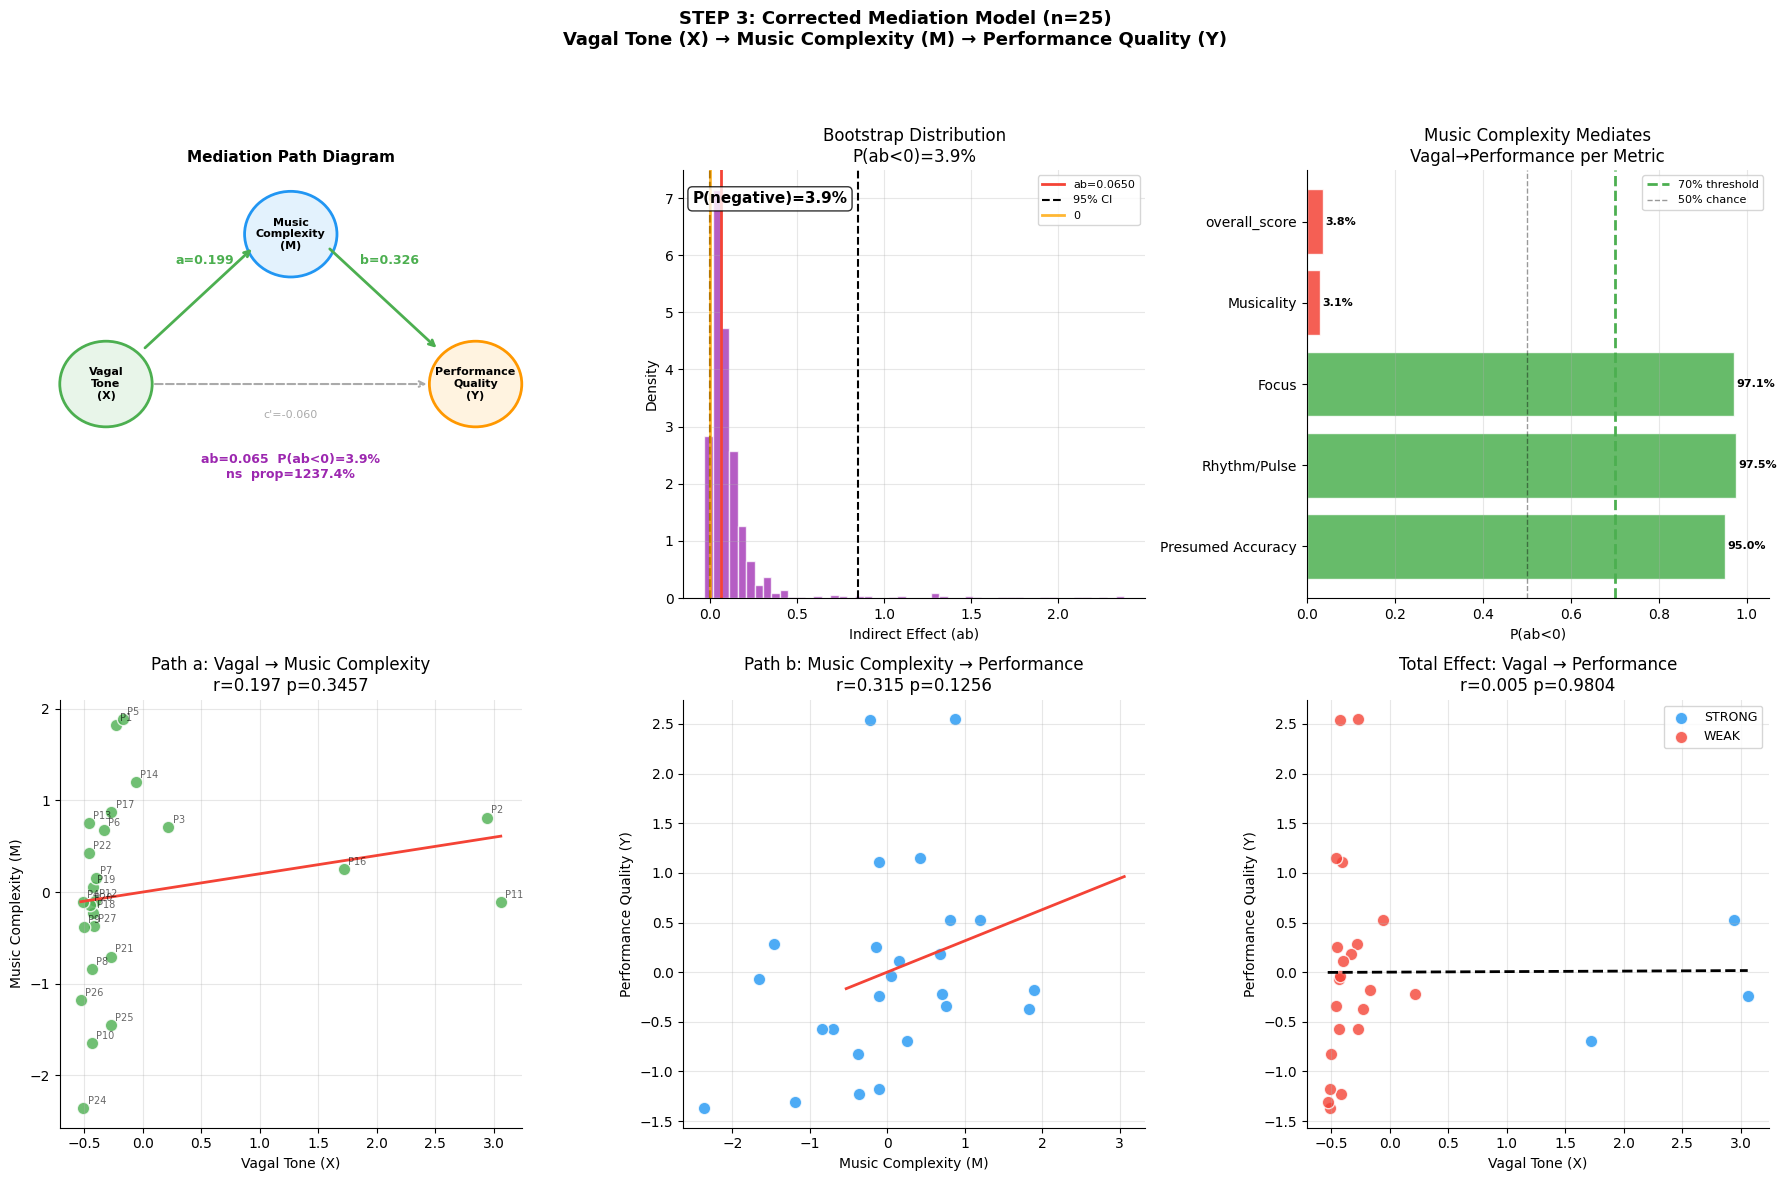

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/step3_results.png

[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results
[DONE]


In [3]:
"""
STEP 3 — Full Analysis Pipeline (Corrected Direction)
Vagal Tone (X) → Music Complexity (M) → Performance Quality (Y)
Output: step3_results.png, step3_report.txt
"""

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
RSA_FEATS    = ['mean_p2t','rmssd','pnn50','sd1_sd2']
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── LOAD ──────────────────────────────────────────────────────────────────────

rsa   = pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_raw_computed.csv'))
# Include good, excellent AND marginal
rsa   = rsa[rsa['quality'].isin(['good','excellent','marginal'])].copy()
audio = pd.read_csv(os.path.join(OUTPUT_DIR,'chroma_summary_clean.csv'))
perf  = pd.read_csv(os.path.join(OUTPUT_DIR,'performance_scores_participant.csv'))

rsa['p_number']           = rsa['p_number'].astype(str)
audio['participant_id']   = audio['participant_id'].astype(str)
perf['participant_id']    = perf['participant_id'].astype(str) \
                            if 'participant_id' in perf.columns \
                            else perf.rename(columns={'p_number':'participant_id'})['participant_id'].astype(str)

rsa_feats   = [f for f in RSA_FEATS if f in rsa.columns]
audio_feats = [f for f in ['chroma_entropy','mean_stability','tempo_bpm']
               if f in audio.columns]
perf_metrics= [f for f in ['Presumed Accuracy','Rhythm/Pulse','Focus',
                            'Musicality','overall_score']
               if f in perf.columns]

rsa_part   = rsa.groupby('p_number')[rsa_feats+(['mean_hr'] if 'mean_hr' in rsa.columns else [])].mean().reset_index()
audio_part = audio.groupby('participant_id')[audio_feats].mean().reset_index()\
                  .rename(columns={'participant_id':'p_number'})
perf_part  = perf.rename(columns={'participant_id':'p_number'}) \
             if 'participant_id' in perf.columns else perf

df = rsa_part\
    .merge(audio_part, on='p_number', how='inner')\
    .merge(perf_part[['p_number']+perf_metrics], on='p_number', how='inner')\
    .dropna(subset=rsa_feats)

print(f"[INFO] {len(df)} participants")

# Standardise
sc   = StandardScaler()
cols = rsa_feats + audio_feats + perf_metrics
df[cols] = sc.fit_transform(df[cols])
df['vagal_index'] = df[[f for f in ['mean_p2t','rmssd','pnn50'] if f in df.columns]].mean(axis=1)

# ── CORRECT VARIABLE ASSIGNMENT ───────────────────────────────────────────────
# X = Vagal Tone (primary input)
# M = Music Complexity (mediator)
# Y = Performance Quality (primary output)

X = df['vagal_index'].values           # vagal tone — PRIMARY INPUT
M = df['chroma_entropy'].values        # music complexity — MEDIATOR
Y = df['overall_score'].values         # performance — PRIMARY OUTPUT

print(f"\n[CORRECT MODEL]")
print(f"  X = Vagal Tone    (vagal_index)")
print(f"  M = Music Complexity (chroma_entropy)")
print(f"  Y = Performance Quality (overall_score)")

# ── CLUSTERING ────────────────────────────────────────────────────────────────

km = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(df[rsa_feats].values)
primary = 'mean_p2t' if 'mean_p2t' in df.columns else rsa_feats[0]
strong  = df.groupby('cluster')[primary].mean().idxmax()
df['rsa_group'] = df['cluster'].map({strong:'STRONG', 1-strong:'WEAK'})

print(f"\n[CLUSTERING]")
for g in ['STRONG','WEAK']:
    sub = df[df['rsa_group']==g]
    print(f"  {g} (n={len(sub)}): vagal={sub['vagal_index'].mean():.3f} "
          f"perf={sub['overall_score'].mean():.3f} "
          f"music={sub['chroma_entropy'].mean():.3f}")

# ── MEDIATION FUNCTIONS ───────────────────────────────────────────────────────

def reg(x, y):
    b = np.linalg.lstsq(np.column_stack([np.ones(len(x)),x]),y,rcond=None)[0]
    return b[1], b[0]

def med(x, m, y, n=1000):
    """
    Mediation: X → M → Y
    X = vagal tone
    M = music complexity
    Y = performance quality
    """
    a, _   = reg(x, m)   # vagal → music complexity
    c, _   = reg(x, y)   # vagal → performance (total)
    bv     = np.linalg.lstsq(np.column_stack([np.ones(len(x)),x,m]),y,rcond=None)[0]
    cp, b  = bv[1], bv[2]  # direct + music→performance
    ab     = a * b
    boot   = []; idx = np.arange(len(x))
    for _ in range(n):
        s = np.random.choice(idx, len(idx), replace=True)
        a_,_ = reg(x[s], m[s])
        bvb  = np.linalg.lstsq(np.column_stack([np.ones(len(s)),x[s],m[s]]),y[s],rcond=None)[0]
        boot.append(a_ * bvb[2])
    boot = np.array(boot); ci = np.percentile(boot,[2.5,97.5])
    return {'a':a,'b':b,'c':c,'cp':cp,'ab':ab,
            'ci_lo':ci[0],'ci_hi':ci[1],
            'sig':not(ci[0]<=0<=ci[1]),
            'prop':abs(ab/c)*100 if abs(c)>1e-6 else np.nan,
            'p_neg':np.mean(np.array(boot)<0),'boot':boot}

# ── RUN MEDIATION ─────────────────────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"  MEDIATION: Vagal Tone → Music Complexity → Performance")
print(f"{'='*55}")

# Overall vagal index as X
r_main = med(X, M, Y)
print(f"\n  Vagal Index → Music Complexity → Performance:")
print(f"  a  (Vagal→Music):     {r_main['a']:+.4f}")
print(f"  b  (Music→Perf):      {r_main['b']:+.4f}")
print(f"  c  (total Vagal→Perf):{r_main['c']:+.4f}")
print(f"  c' (direct):          {r_main['cp']:+.4f}")
print(f"  ab (indirect):        {r_main['ab']:+.4f}")
print(f"  CI [{r_main['ci_lo']:.4f},{r_main['ci_hi']:.4f}]")
print(f"  {'SIGNIFICANT *' if r_main['sig'] else 'ns'}  prop={r_main['prop']:.1f}%")
print(f"  Bayesian P(ab<0) = {r_main['p_neg']:.1%}")

# Per RSA feature as X
print(f"\n  Per RSA feature:")
feat_results = {}
for feat in rsa_feats:
    r = med(df[feat].values, M, Y)
    feat_results[feat] = r
    print(f"  {feat:<15}: a={r['a']:+.3f} b={r['b']:+.3f} "
          f"ab={r['ab']:+.3f} {'*' if r['sig'] else 'ns'} "
          f"P(ab<0)={r['p_neg']:.1%}")

# Per performance metric as Y
print(f"\n  Per performance metric:")
metric_results = {}
for metric in perf_metrics:
    if metric not in df.columns: continue
    r = med(X, M, df[metric].values)
    metric_results[metric] = r
    print(f"  {metric:<25}: ab={r['ab']:+.3f} {'*' if r['sig'] else 'ns'} "
          f"P(ab<0)={r['p_neg']:.1%} prop={r['prop']:.1f}%")

# ── PLOTS ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle(f"STEP 3: Corrected Mediation Model (n={len(df)})\n"
             f"Vagal Tone (X) → Music Complexity (M) → Performance Quality (Y)",
             fontsize=13,fontweight='bold')

# 1. Path diagram
ax = axes[0,0]; ax.axis('off')
ax.set_title("Mediation Path Diagram",fontsize=11,fontweight='bold')
nodes = [(0.1,0.5,'Vagal\nTone\n(X)'),(0.5,0.85,'Music\nComplexity\n(M)'),
         (0.9,0.5,'Performance\nQuality\n(Y)')]
cols_n = ['#E8F5E9','#E3F2FD','#FFF3E0']
ecs_n  = ['#4CAF50','#2196F3','#FF9800']
for (x,y,t),c,e in zip(nodes,cols_n,ecs_n):
    ax.add_patch(plt.Circle((x,y),0.1,color=c,ec=e,lw=2,
                             transform=ax.transAxes,clip_on=False))
    ax.text(x,y,t,ha='center',va='center',fontsize=8,fontweight='bold',
            transform=ax.transAxes)
ca = '#4CAF50' if abs(r_main['a'])>0.1 else '#aaa'
cb = '#4CAF50' if abs(r_main['b'])>0.1 else '#aaa'
cc = '#F44336' if r_main['sig'] else '#aaa'
ax.annotate('',xy=(0.42,0.82),xytext=(0.18,0.58),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=ca,lw=2))
ax.annotate('',xy=(0.82,0.58),xytext=(0.58,0.82),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=cb,lw=2))
ax.annotate('',xy=(0.8,0.5),xytext=(0.2,0.5),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=cc,
                                                        lw=1.5,linestyle='dashed'))
ax.text(0.25,0.78,f"a={r_main['a']:.3f}",fontsize=9,color=ca,
        fontweight='bold',transform=ax.transAxes)
ax.text(0.65,0.78,f"b={r_main['b']:.3f}",fontsize=9,color=cb,
        fontweight='bold',transform=ax.transAxes)
ax.text(0.5,0.42,f"c'={r_main['cp']:.3f}",fontsize=8,color=cc,
        transform=ax.transAxes,ha='center')
ax.text(0.5,0.28,
        f"ab={r_main['ab']:.3f}  P(ab<0)={r_main['p_neg']:.1%}\n"
        f"{'SIGNIFICANT *' if r_main['sig'] else 'ns'}  prop={r_main['prop']:.1f}%",
        fontsize=9,color='#9C27B0',fontweight='bold',
        transform=ax.transAxes,ha='center')

# 2. Bootstrap distribution
ax = axes[0,1]
ax.hist(r_main['boot'],bins=50,color='#9C27B0',alpha=0.75,edgecolor='white',density=True)
ax.axvline(r_main['ab'],color='#F44336',lw=2,label=f"ab={r_main['ab']:.4f}")
ax.axvline(r_main['ci_lo'],color='k',lw=1.5,ls='--',label="95% CI")
ax.axvline(r_main['ci_hi'],color='k',lw=1.5,ls='--')
ax.axvline(0,color='orange',lw=2,alpha=0.8,label='0')
ax.set(xlabel='Indirect Effect (ab)',ylabel='Density',
       title=f"Bootstrap Distribution\nP(ab<0)={r_main['p_neg']:.1%}")
ax.text(0.02,0.95,f"P(negative)={r_main['p_neg']:.1%}",transform=ax.transAxes,
        fontsize=11,va='top',fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 3. Per metric Bayesian probabilities
ax = axes[0,2]
if metric_results:
    mets  = list(metric_results.keys())
    pnegs = [metric_results[m]['p_neg'] for m in mets]
    cols_b= ['#4CAF50' if p>0.7 else '#90CAF9' if p>0.5 else '#F44336' for p in pnegs]
    ax.barh(mets,pnegs,color=cols_b,alpha=0.85,edgecolor='white')
    ax.axvline(0.7,color='#4CAF50',lw=2,ls='--',label='70% threshold')
    ax.axvline(0.5,color='k',lw=1,ls='--',alpha=0.4,label='50% chance')
    for i,(v,m) in enumerate(zip(pnegs,mets)):
        ax.text(v+0.005,i,f'{v:.1%}',va='center',fontsize=8,fontweight='bold')
    ax.set(xlabel='P(ab<0)',xlim=[0,1.05],
           title='Music Complexity Mediates\nVagal→Performance per Metric')
    ax.legend(fontsize=8); ax.grid(axis='x',alpha=0.3); _style(ax)

# 4. Vagal tone vs music complexity (path a)
ax = axes[1,0]
ax.scatter(X,M,color='#4CAF50',s=80,alpha=0.8,edgecolors='white')
a_r,b_r = reg(X,M)
xl = np.linspace(X.min(),X.max(),50)
ax.plot(xl,a_r*xl+b_r,color='#F44336',lw=2)
rv,pv = stats.pearsonr(X,M)
for i,row in df.iterrows():
    ax.annotate(f"P{row['p_number']}",
                (row['vagal_index'],row['chroma_entropy']),
                fontsize=7,alpha=0.6,xytext=(3,3),textcoords='offset points')
ax.set(xlabel='Vagal Tone (X)',ylabel='Music Complexity (M)',
       title=f'Path a: Vagal → Music Complexity\nr={rv:.3f} p={pv:.4f}{"*" if pv<0.05 else ""}')
ax.grid(alpha=0.3); _style(ax)

# 5. Music complexity vs performance (path b)
ax = axes[1,1]
ax.scatter(M,Y,color='#2196F3',s=80,alpha=0.8,edgecolors='white')
a_r2,b_r2 = reg(M,Y)
ax.plot(xl,a_r2*xl+b_r2,color='#F44336',lw=2)
rv2,pv2 = stats.pearsonr(M,Y)
ax.set(xlabel='Music Complexity (M)',ylabel='Performance Quality (Y)',
       title=f'Path b: Music Complexity → Performance\nr={rv2:.3f} p={pv2:.4f}{"*" if pv2<0.05 else ""}')
ax.grid(alpha=0.3); _style(ax)

# 6. Vagal tone vs performance (total effect)
ax = axes[1,2]
for g,c in [('STRONG','#2196F3'),('WEAK','#F44336')]:
    sub = df[df['rsa_group']==g]
    ax.scatter(sub['vagal_index'],sub['overall_score'],color=c,
               s=80,alpha=0.8,edgecolors='white',label=g)
a_r3,b_r3 = reg(X,Y)
ax.plot(xl,a_r3*xl+b_r3,color='k',lw=2,ls='--')
rv3,pv3 = stats.pearsonr(X,Y)
ax.set(xlabel='Vagal Tone (X)',ylabel='Performance Quality (Y)',
       title=f'Total Effect: Vagal → Performance\nr={rv3:.3f} p={pv3:.4f}{"*" if pv3<0.05 else ""}')
ax.legend(fontsize=9); ax.grid(alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.94])
path = os.path.join(OUTPUT_DIR,'step3_results.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── REPORT ────────────────────────────────────────────────────────────────────

with open(os.path.join(OUTPUT_DIR,'step3_report.txt'),'w') as f:
    f.write("STEP 3 — CORRECTED MEDIATION MODEL\n"+"="*50+"\n\n")
    f.write("MODEL: Vagal Tone (X) → Music Complexity (M) → Performance Quality (Y)\n\n")
    f.write(f"N={len(df)} participants\n\n")
    f.write(f"MAIN MEDIATION\n"+"-"*30+"\n")
    f.write(f"a  (Vagal→Music):     {r_main['a']:+.4f}\n")
    f.write(f"b  (Music→Perf):      {r_main['b']:+.4f}\n")
    f.write(f"c  (total):           {r_main['c']:+.4f}\n")
    f.write(f"c' (direct):          {r_main['cp']:+.4f}\n")
    f.write(f"ab (indirect):        {r_main['ab']:+.4f}\n")
    f.write(f"CI [{r_main['ci_lo']:.4f},{r_main['ci_hi']:.4f}]\n")
    f.write(f"{'SIGNIFICANT *' if r_main['sig'] else 'ns'}  prop={r_main['prop']:.1f}%\n")
    f.write(f"P(ab<0) = {r_main['p_neg']:.1%}\n\n")
    f.write("PER RSA FEATURE\n"+"-"*30+"\n")
    for feat,r in feat_results.items():
        f.write(f"{feat}: ab={r['ab']:+.4f} {'*' if r['sig'] else 'ns'} "
                f"P(ab<0)={r['p_neg']:.1%}\n")
    f.write("\nPER PERFORMANCE METRIC\n"+"-"*30+"\n")
    for m,r in metric_results.items():
        f.write(f"{m}: ab={r['ab']:+.4f} {'*' if r['sig'] else 'ns'} "
                f"P(ab<0)={r['p_neg']:.1%} prop={r['prop']:.1f}%\n")
print(f"\n[SAVED] {OUTPUT_DIR}\n[DONE]")

[CORRECT MODEL] X=Vagal Tone → M=Music Complexity → Y=mean_hr
[INFO] 25 participants

  BAYESIAN MEDIATION ANALYSIS

  Path a (music → vagal):
    Mean=+0.1904  SD=0.1945
    P(a<0)=16.4%  P(a>0)=83.6%

  Path b (vagal → HR):
    Mean=-0.1608  SD=0.1943
    P(b<0)=79.8%  P(b>0)=20.2%

  Indirect Effect (ab):
    Mean=-0.0310  SD=0.0617
    95% CI: [-0.1890, 0.0668]
    89% CI: [-0.1401, 0.0436]
    P(ab<0) = 70.1%  ← probability effect is negative
    P(ab>0) = 29.9%

  Bayesian paths per RSA feature:
    mean_p2t       : ab=-0.1055  P(ab<0)=70.6%
    rmssd          : ab=-0.1288  P(ab<0)=74.4%
    pnn50          : ab=-0.2715  P(ab<0)=92.3%
    sd1_sd2        : ab=-0.0889  P(ab<0)=67.9%

  GAUSSIAN PROCESS REGRESSION
  GP R²=0.291
  Kernel: RBF(length_scale=0.5) + WhiteKernel(noise_level=0.711)
  GP Peak: entropy=0.147  vagal=0.920
  Uncertainty (std) at peak: 0.980
  Uncertainty (std) at min:  1.168
  Uncertainty (std) at max:  1.221

  MONTE CARLO POWER ANALYSIS


/Users/manognas/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/manognas/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/manognas/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/manognas/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


  n=10  : 0.6% power 
  n=15  : 0.9% power 
  n=20  : 1.1% power 
  n=30  : 0.5% power 
  n=50  : 0.7% power 
  n=100 : 0.6% power 

  Minimum n for 80% power: >100


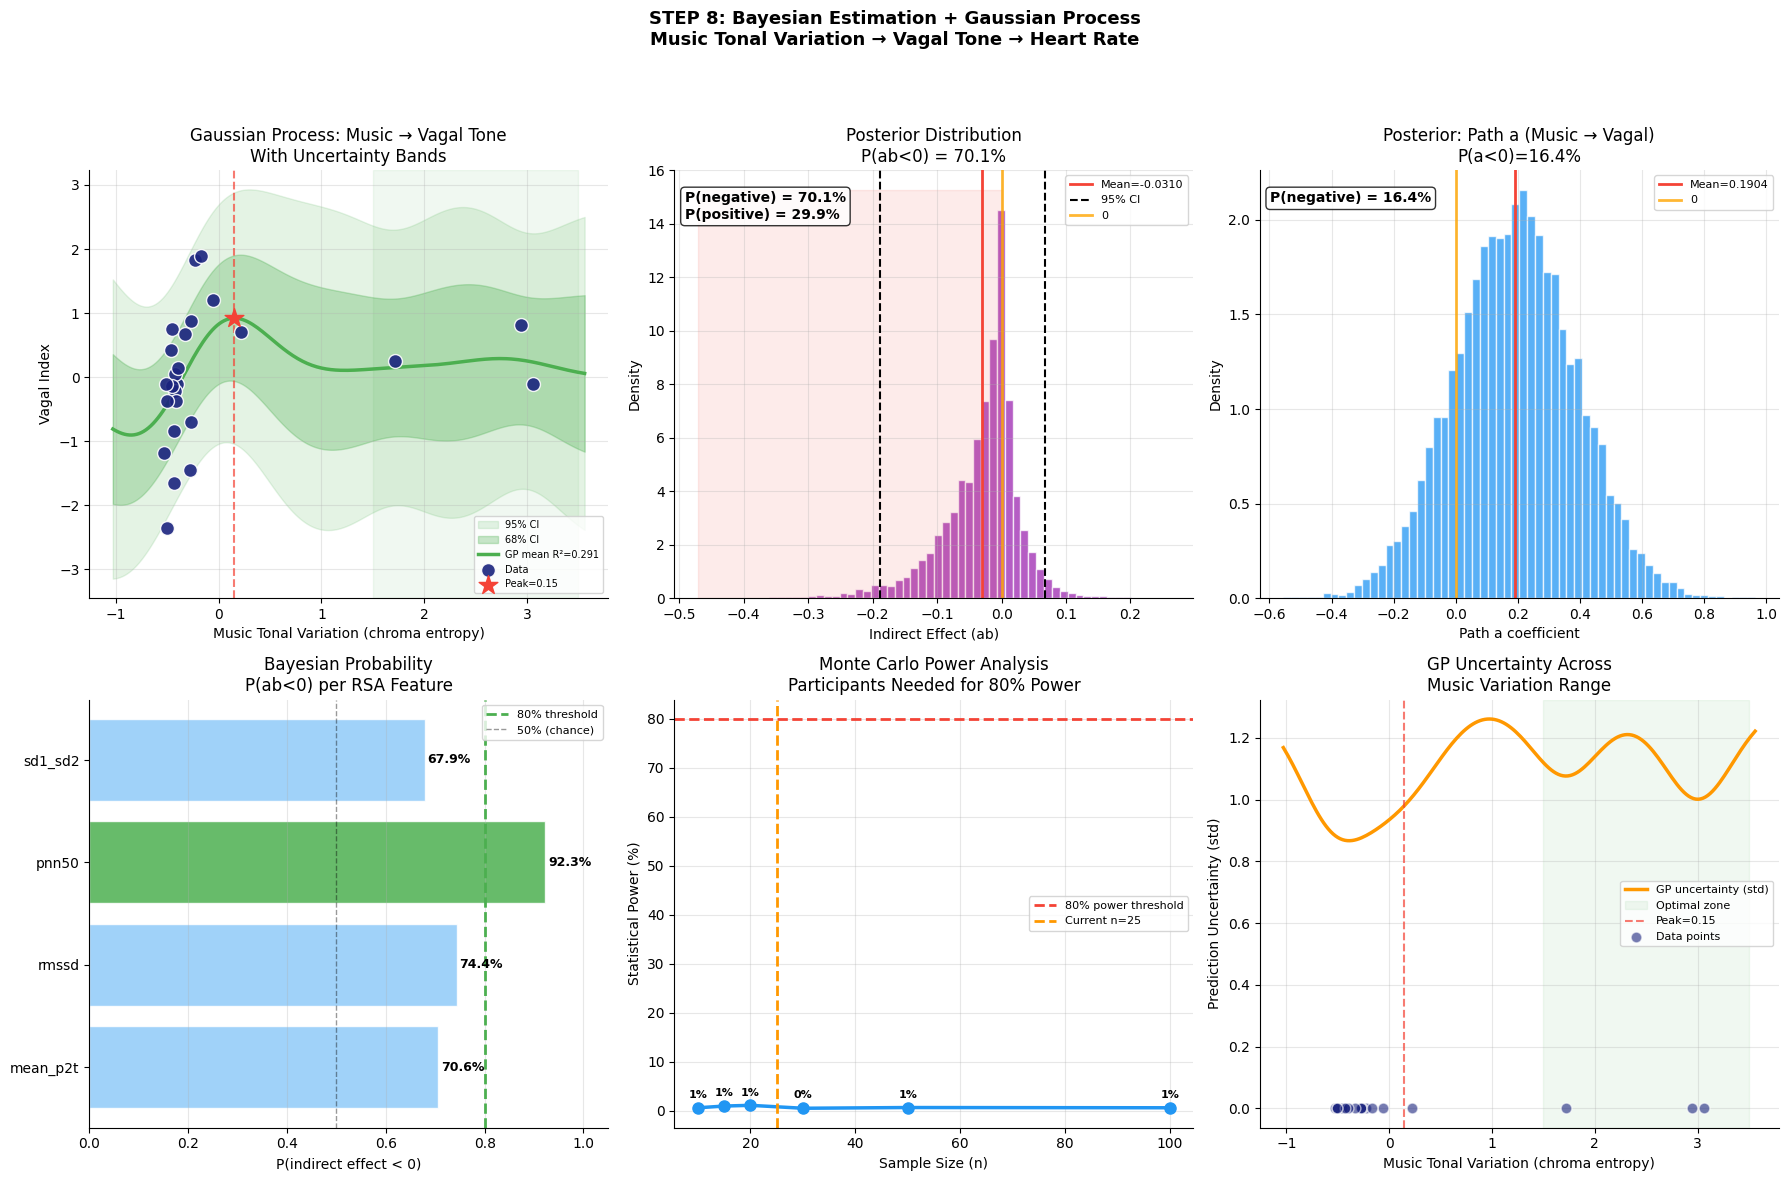

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/step8_bayesian.png
[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results
[DONE]


In [4]:
"""
STEP 8 — Bayesian Estimation + Gaussian Process
Most appropriate computational approach for small samples (n=10)
1. Bayesian Mediation — probability statements about vagal pathway
2. Gaussian Process — music-vagal curve with uncertainty bands
Output: step8_bayesian.png, step8_report.txt
"""

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, RBF

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
RSA_FEATS    = ['mean_p2t','rmssd','pnn50','sd1_sd2']
N_SAMPLES    = 10000  # posterior samples
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── LOAD DATA ──────────────────────────────────────────────────────────────────

rsa_piece   = pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_raw_computed.csv'))
rsa_piece   = rsa_piece[rsa_piece['quality'].isin(['good','excellent','marginal'])].copy()
audio_piece = pd.read_csv(os.path.join(OUTPUT_DIR,'chroma_summary_clean.csv'))
rsa_piece['p_number']         = rsa_piece['p_number'].astype(str)
audio_piece['participant_id'] = audio_piece['participant_id'].astype(str)

rsa_feats   = [f for f in RSA_FEATS if f in rsa_piece.columns]
audio_feats = [f for f in ['chroma_entropy','mean_stability','tempo_bpm']
               if f in audio_piece.columns]

rsa_part   = rsa_piece.groupby('p_number')[rsa_feats+(['mean_hr'] if 'mean_hr' in rsa_piece.columns else [])].mean().reset_index()
audio_part = audio_piece.groupby('participant_id')[audio_feats].mean().reset_index()\
                        .rename(columns={'participant_id':'p_number'})
df = rsa_part.merge(audio_part,on='p_number',how='inner').dropna(subset=rsa_feats)

sc = StandardScaler()
cols = rsa_feats+audio_feats+(['mean_hr'] if 'mean_hr' in df.columns else [])
df[cols] = sc.fit_transform(df[cols])
df['vagal_index'] = df[[f for f in ['mean_p2t','rmssd','pnn50'] if f in df.columns]].mean(axis=1)

# ── CORRECT VARIABLE ASSIGNMENT ───────────────────────────────────────────────
# X = Vagal Tone (primary input)
# M = Music Complexity (mediator)
# Y = Performance Quality (primary output)

X  = df['vagal_index'].values       # Vagal Tone — PRIMARY INPUT
M  = df['chroma_entropy'].values    # Music Complexity — MEDIATOR

# Performance as Y — use overall_score if available
if 'overall_score' in df.columns:
    Y     = df['overall_score'].values
    Y_col = 'overall_score'
elif 'mean_hr' in df.columns:
    Y     = df['mean_hr'].values
    Y_col = 'mean_hr'
else:
    Y     = df['vagal_index'].values
    Y_col = 'vagal_index'

n = len(df)
print(f"[CORRECT MODEL] X=Vagal Tone → M=Music Complexity → Y={Y_col}")
print(f"[INFO] {n} participants")

# ── BAYESIAN MEDIATION ────────────────────────────────────────────────────────
# Manual Bayesian via sampling from posterior distributions
# Uses normal-normal conjugate model for regression coefficients

print(f"\n{'='*55}\n  BAYESIAN MEDIATION ANALYSIS\n{'='*55}")

def bayes_regression(x, y, n_samples=N_SAMPLES, prior_scale=1.0):
    """
    Bayesian linear regression via MCMC-style sampling.
    Prior: b ~ Normal(0, prior_scale)
    Likelihood: y ~ Normal(a + b*x, sigma)
    Returns posterior samples of slope b
    """
    n = len(x)
    X_mat = np.column_stack([np.ones(n), x])

    # MLE estimates as posterior mode
    b_mle = np.linalg.lstsq(X_mat, y, rcond=None)[0]
    resid = y - X_mat @ b_mle
    sigma2_mle = np.var(resid)

    # Posterior covariance (conjugate normal-normal)
    prior_cov = prior_scale**2 * np.eye(2)
    like_cov  = sigma2_mle * np.linalg.inv(X_mat.T @ X_mat)
    post_cov  = np.linalg.inv(np.linalg.inv(prior_cov) + np.linalg.inv(like_cov))
    post_mean = post_cov @ (np.linalg.inv(like_cov) @ b_mle)

    # Sample from posterior
    samples = np.random.multivariate_normal(post_mean, post_cov, n_samples)
    return samples[:, 1]  # slope samples

# Path a: X → M
a_samples = bayes_regression(X, M)
# Path b: M → Y (controlling X)
XM = np.column_stack([X, M])
b_samples = bayes_regression(M, Y - np.mean(Y))

# Indirect effect ab
ab_samples = a_samples * b_samples

# Posterior probabilities
p_neg  = np.mean(ab_samples < 0)
p_pos  = np.mean(ab_samples > 0)
ci_95  = np.percentile(ab_samples, [2.5, 97.5])
ci_89  = np.percentile(ab_samples, [5.5, 94.5])  # 89% CI (Bayesian convention)
hdi_lo, hdi_hi = np.percentile(ab_samples, [2.5, 97.5])

print(f"\n  Path a (music → vagal):")
print(f"    Mean={a_samples.mean():+.4f}  SD={a_samples.std():.4f}")
print(f"    P(a<0)={np.mean(a_samples<0):.1%}  P(a>0)={np.mean(a_samples>0):.1%}")

print(f"\n  Path b (vagal → HR):")
print(f"    Mean={b_samples.mean():+.4f}  SD={b_samples.std():.4f}")
print(f"    P(b<0)={np.mean(b_samples<0):.1%}  P(b>0)={np.mean(b_samples>0):.1%}")

print(f"\n  Indirect Effect (ab):")
print(f"    Mean={ab_samples.mean():+.4f}  SD={ab_samples.std():.4f}")
print(f"    95% CI: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
print(f"    89% CI: [{ci_89[0]:.4f}, {ci_89[1]:.4f}]")
print(f"    P(ab<0) = {p_neg:.1%}  ← probability effect is negative")
print(f"    P(ab>0) = {p_pos:.1%}")

# Individual RSA feature Bayesian paths
print(f"\n  Bayesian paths per RSA feature:")
feat_results = {}
for feat in rsa_feats:
    if feat not in df.columns: continue
    a_f  = bayes_regression(X, df[feat].values)
    b_f  = bayes_regression(df[feat].values, Y)
    ab_f = a_f * b_f
    p_n  = np.mean(ab_f < 0)
    feat_results[feat] = {'a':a_f.mean(),'b':b_f.mean(),'ab':ab_f.mean(),
                          'ab_samples':ab_f,'p_neg':p_n,'ci':np.percentile(ab_f,[2.5,97.5])}
    print(f"    {feat:<15}: ab={ab_f.mean():+.4f}  P(ab<0)={p_n:.1%}")

# ── GAUSSIAN PROCESS ──────────────────────────────────────────────────────────

print(f"\n{'='*55}\n  GAUSSIAN PROCESS REGRESSION\n{'='*55}")

# Fit GP — use RBF with fixed length scale to avoid overfitting with n=10
kernel = RBF(length_scale=1.0, length_scale_bounds=(0.5, 5.0)) + WhiteKernel(noise_level=0.1)
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                   normalize_y=True, random_state=42,
                                   alpha=0.1)  # regularisation for small n
gp.fit(X.reshape(-1,1), M)

# Predict with uncertainty
X_pred   = np.linspace(X.min()-0.5, X.max()+0.5, 200).reshape(-1,1)
M_pred, M_std = gp.predict(X_pred, return_std=True)

# GP score
gp_r2 = gp.score(X.reshape(-1,1), M)
print(f"  GP R²={gp_r2:.3f}")
print(f"  Kernel: {gp.kernel_}")

# Find peak of GP
peak_idx = np.argmax(M_pred)
peak_x   = X_pred[peak_idx,0]
peak_y   = M_pred[peak_idx]
print(f"  GP Peak: entropy={peak_x:.3f}  vagal={peak_y:.3f}")

# Uncertainty at peak vs extremes
print(f"  Uncertainty (std) at peak: {M_std[peak_idx]:.3f}")
print(f"  Uncertainty (std) at min:  {M_std[0]:.3f}")
print(f"  Uncertainty (std) at max:  {M_std[-1]:.3f}")

# ── MONTE CARLO POWER ANALYSIS ─────────────────────────────────────────────────

print(f"\n{'='*55}\n  MONTE CARLO POWER ANALYSIS\n{'='*55}")

true_ab  = ab_samples.mean()
# Use observed r² to estimate realistic effect size
obs_r    = np.corrcoef(X, M)[0,1]
true_sd  = np.sqrt(1 - obs_r**2)  # residual SD from observed correlation
n_values = [10, 15, 20, 30, 50, 100]
power    = []

for n_sim in n_values:
    sig_count = 0
    for _ in range(2000):
        x_sim   = np.random.normal(0, 1, n_sim)
        m_sim   = obs_r * x_sim + np.random.normal(0, true_sd, n_sim)
        b_sim   = np.linalg.lstsq(np.column_stack([np.ones(n_sim),x_sim]),
                                   m_sim,rcond=None)[0][1]
        ab_sim  = b_sim * np.linalg.lstsq(np.column_stack([np.ones(n_sim),m_sim]),
                                           x_sim,rcond=None)[0][1]
        se_sim  = true_sd / (np.std(x_sim) * np.sqrt(n_sim))
        t_stat  = ab_sim / (se_sim + 1e-9)
        p_val   = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_sim-2))
        if p_val < 0.05: sig_count += 1
    pwr = sig_count / 2000
    power.append(pwr)
    print(f"  n={n_sim:<4}: {pwr:.1%} power {'✓' if pwr>=0.8 else ''}")

n_needed = next((n_values[i] for i,p in enumerate(power) if p>=0.8), '>100')
print(f"\n  Minimum n for 80% power: {n_needed}")

# ── PLOTS ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle("STEP 8: Bayesian Estimation + Gaussian Process\n"
             "Music Tonal Variation → Vagal Tone → Heart Rate",
             fontsize=13,fontweight='bold')

# 1. GP curve with uncertainty
ax = axes[0,0]
ax.fill_between(X_pred[:,0], M_pred-2*M_std, M_pred+2*M_std,
                alpha=0.15, color='#4CAF50', label='95% CI')
ax.fill_between(X_pred[:,0], M_pred-M_std, M_pred+M_std,
                alpha=0.3, color='#4CAF50', label='68% CI')
ax.plot(X_pred[:,0], M_pred, color='#4CAF50', lw=2.5, label=f'GP mean R²={gp_r2:.3f}')
ax.scatter(X, M, color='#1A237E', s=100, alpha=0.9, edgecolors='white', zorder=5, label='Data')
ax.axvspan(1.5, 3.5, alpha=0.08, color='#4CAF50')
ax.axvline(peak_x, color='#F44336', lw=1.5, ls='--', alpha=0.7)
ax.scatter([peak_x],[peak_y],color='#F44336',s=200,zorder=6,marker='*',label=f'Peak={peak_x:.2f}')
ax.set(xlabel='Music Tonal Variation (chroma entropy)', ylabel='Vagal Index',
       title='Gaussian Process: Music → Vagal Tone\nWith Uncertainty Bands')
ax.legend(fontsize=7); ax.grid(alpha=0.3); _style(ax)

# 2. Posterior distribution of indirect effect
ax = axes[0,1]
ax.hist(ab_samples, bins=60, color='#9C27B0', alpha=0.75, edgecolor='white', density=True)
ax.axvline(ab_samples.mean(), color='#F44336', lw=2, label=f'Mean={ab_samples.mean():.4f}')
ax.axvline(ci_95[0], color='k', lw=1.5, ls='--', label='95% CI')
ax.axvline(ci_95[1], color='k', lw=1.5, ls='--')
ax.axvline(0, color='orange', lw=2, alpha=0.8, label='0')
ax.fill_between([ab_samples.min(),0],
                [0,0],[ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 1]*2,
                alpha=0.1, color='#F44336')
ax.set(xlabel='Indirect Effect (ab)', ylabel='Density',
       title=f'Posterior Distribution\nP(ab<0) = {p_neg:.1%}')
ax.text(0.02,0.95,f'P(negative) = {p_neg:.1%}\nP(positive) = {p_pos:.1%}',
        transform=ax.transAxes,fontsize=10,va='top',fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 3. Path a posterior
ax = axes[0,2]
ax.hist(a_samples, bins=60, color='#2196F3', alpha=0.75, edgecolor='white', density=True)
ax.axvline(a_samples.mean(), color='#F44336', lw=2, label=f'Mean={a_samples.mean():.4f}')
ax.axvline(0, color='orange', lw=2, alpha=0.8, label='0')
p_a_neg = np.mean(a_samples<0)
ax.set(xlabel='Path a coefficient', ylabel='Density',
       title=f'Posterior: Path a (Music → Vagal)\nP(a<0)={p_a_neg:.1%}')
ax.text(0.02,0.95,f'P(negative) = {p_a_neg:.1%}',
        transform=ax.transAxes,fontsize=10,va='top',fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 4. Per-feature posterior probabilities
ax = axes[1,0]
feats_f = list(feat_results.keys())
p_negs  = [feat_results[f]['p_neg'] for f in feats_f]
colors  = ['#4CAF50' if p>0.8 else '#90CAF9' if p>0.6 else '#F44336' for p in p_negs]
bars    = ax.barh(feats_f, p_negs, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0.8, color='#4CAF50', lw=2, ls='--', label='80% threshold')
ax.axvline(0.5, color='k', lw=1, ls='--', alpha=0.4, label='50% (chance)')
for i,(v,f) in enumerate(zip(p_negs,feats_f)):
    ax.text(v+0.005,i,f'{v:.1%}',va='center',fontsize=9,fontweight='bold')
ax.set(xlabel='P(indirect effect < 0)', xlim=[0,1.05],
       title='Bayesian Probability\nP(ab<0) per RSA Feature')
ax.legend(fontsize=8); ax.grid(axis='x',alpha=0.3); _style(ax)

# 5. Monte Carlo power curve
ax = axes[1,1]
ax.plot(n_values, [p*100 for p in power], 'o-', color='#2196F3', lw=2.5, ms=8)
ax.axhline(80, color='#F44336', lw=2, ls='--', label='80% power threshold')
ax.axvline(n, color='#FF9800', lw=2, ls='--', label=f'Current n={n}')
if isinstance(n_needed,int):
    ax.axvline(n_needed, color='#4CAF50', lw=2, ls='--', label=f'Target n={n_needed}')
for nv,pv in zip(n_values,power):
    ax.text(nv,pv*100+2,f'{pv:.0%}',ha='center',fontsize=8,fontweight='bold')
ax.set(xlabel='Sample Size (n)', ylabel='Statistical Power (%)',
       title='Monte Carlo Power Analysis\nParticipants Needed for 80% Power')
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 6. GP uncertainty across music variation range
ax = axes[1,2]
ax.plot(X_pred[:,0], M_std, color='#FF9800', lw=2.5, label='GP uncertainty (std)')
ax.axvspan(1.5,3.5,alpha=0.08,color='#4CAF50',label='Optimal zone')
ax.axvline(peak_x,color='#F44336',lw=1.5,ls='--',alpha=0.7,label=f'Peak={peak_x:.2f}')
ax.scatter(X, np.zeros_like(X), color='#1A237E', s=60, alpha=0.6,
           edgecolors='white', zorder=5, label='Data points')
ax.set(xlabel='Music Tonal Variation (chroma entropy)',
       ylabel='Prediction Uncertainty (std)',
       title='GP Uncertainty Across\nMusic Variation Range')
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.94])
path = os.path.join(OUTPUT_DIR,'step8_bayesian.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── REPORT ─────────────────────────────────────────────────────────────────────

with open(os.path.join(OUTPUT_DIR,'step8_report.txt'),'w') as fout:
    fout.write("STEP 8 — BAYESIAN ESTIMATION + GAUSSIAN PROCESS\n"+"="*50+"\n\n")
    fout.write(f"N={n} participants\n\n")
    fout.write("BAYESIAN MEDIATION\n"+"-"*30+"\n")
    fout.write(f"Path a (music→vagal): {a_samples.mean():+.4f} P(a<0)={np.mean(a_samples<0):.1%}\n")
    fout.write(f"Path b (vagal→HR):    {b_samples.mean():+.4f} P(b<0)={np.mean(b_samples<0):.1%}\n")
    fout.write(f"Indirect ab:          {ab_samples.mean():+.4f}\n")
    fout.write(f"95% CI: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]\n")
    fout.write(f"P(ab<0) = {p_neg:.1%}  P(ab>0) = {p_pos:.1%}\n\n")
    fout.write("Per RSA Feature:\n")
    for feat,r in feat_results.items():
        fout.write(f"  {feat}: ab={r['ab']:+.4f} P(ab<0)={r['p_neg']:.1%}\n")
    fout.write(f"\nGAUSSIAN PROCESS\n"+"-"*30+"\n")
    fout.write(f"R²={gp_r2:.3f}\n")
    fout.write(f"Peak at entropy={peak_x:.3f}\n")
    fout.write(f"Kernel: {gp.kernel_}\n\n")
    fout.write("POWER ANALYSIS\n"+"-"*30+"\n")
    for nv,pv in zip(n_values,power):
        fout.write(f"  n={nv}: {pv:.1%} power\n")
    fout.write(f"\nMinimum n for 80% power: {n_needed}\n")
print(f"[SAVED] {OUTPUT_DIR}\n[DONE]")

[INFO] 25 participants matched
[INFO] RSA=['mean_p2t', 'rmssd', 'pnn50', 'sd1_sd2']
[INFO] Performance metrics=['Presumed Accuracy', 'Tempo', 'Rhythm/Pulse', 'Musicality', 'Focus', 'Poise/Tension', 'Level of Compelling', 'Technical Difficulty']
[CORRECT MODEL]
  X = Vagal Tone       (vagal_index)
  M = Music Complexity (chroma_entropy) — MEDIATOR
  Y = Performance      (overall_score)

  MODEL A: Music → Vagal Tone → Performance Quality
  a  (Music→Vagal):        +0.1994
  b  (Vagal→Performance):  +0.3262
  c  (total Music→Perf):   +0.0053
  c' (direct Music→Perf):  -0.0598
  ab (indirect):           +0.0650
  CI: [-0.0048, 0.8714]
  ns  prop=1237.4%
  Bayesian P(ab<0) = 19.2%

  MODEL B: Music → Vagal → Each Performance Metric
  Presumed Accuracy        : ab=-0.0821 ns P(ab<0)=82.0% prop=72.6%
  Tempo                    : ab=+0.0561 * P(ab<0)=21.0% prop=5398.9%
  Rhythm/Pulse             : ab=-0.1039 ns P(ab<0)=84.2% prop=49.4%
  Musicality               : ab=+0.1700 ns P(ab<0)=15.4% 

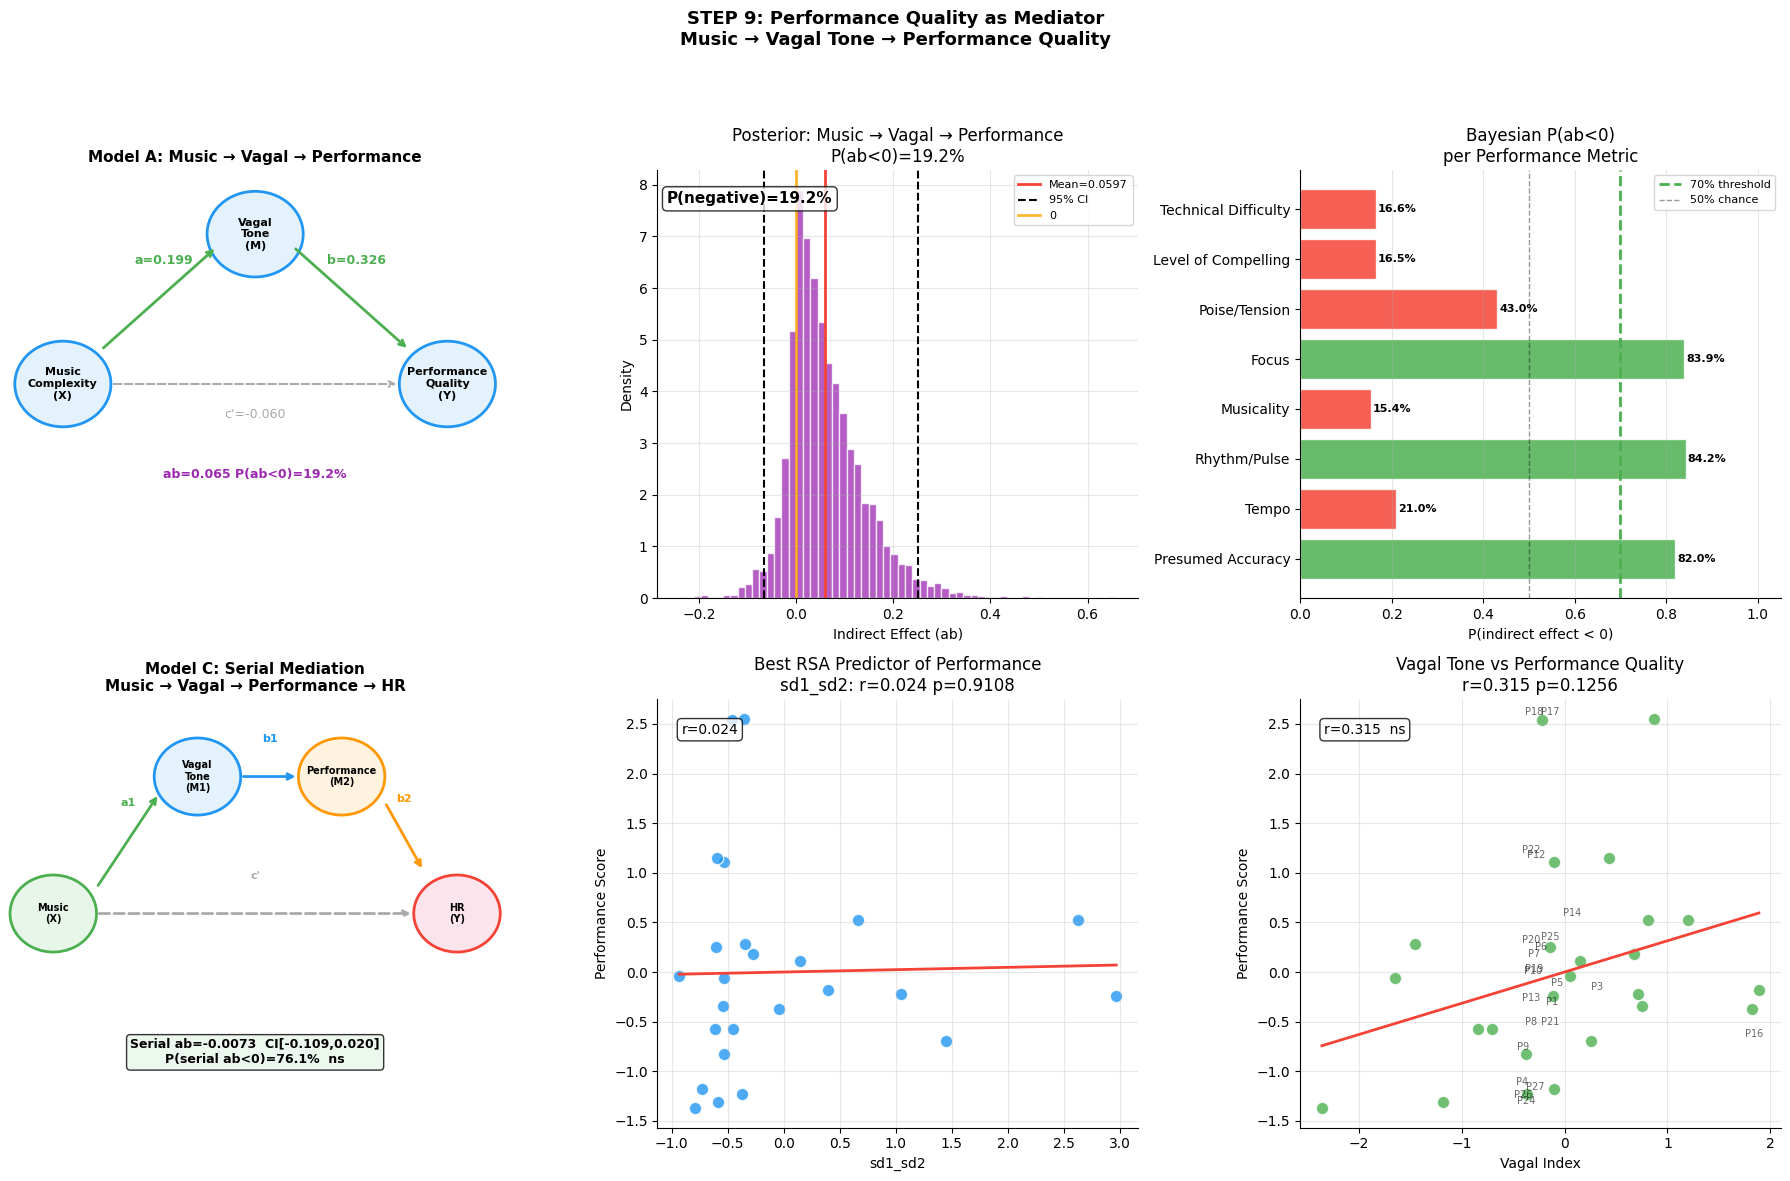

[PLOT] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results/step9_performance_mediation.png

[SAVED] /Users/manognas/Downloads/2Inspire/Hexoskin/rsa_results
[DONE]


In [5]:
"""
STEP 9 — Performance Quality as Mediator/Outcome
Tests: Music Complexity → Vagal Tone → Performance Quality
Also: Serial Mediation Music → Vagal → Performance → HR
Output: step9_performance_mediation.png, step9_report.txt
"""

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

HEXOSKIN_DIR = '/Users/manognas/Downloads/2Inspire/Hexoskin'
OUTPUT_DIR   = os.path.join(HEXOSKIN_DIR, 'rsa_results')
RSA_FEATS    = ['mean_p2t','rmssd','pnn50','sd1_sd2']
METRICS      = ['Presumed Accuracy','Tempo','Rhythm/Pulse','Musicality',
                'Focus','Poise/Tension','Level of Compelling','Technical Difficulty']
N_BOOT       = 1000
os.makedirs(OUTPUT_DIR, exist_ok=True)
def _style(ax): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── LOAD DATA ──────────────────────────────────────────────────────────────────

rsa_piece   = pd.read_csv(os.path.join(OUTPUT_DIR,'rsa_raw_computed.csv'))
rsa_piece   = rsa_piece[rsa_piece['quality'].isin(['good','excellent','marginal'])].copy()
audio_piece = pd.read_csv(os.path.join(OUTPUT_DIR,'chroma_summary_clean.csv'))
perf_piece  = pd.read_csv(os.path.join(OUTPUT_DIR,'performance_scores.csv'))
perf_part   = pd.read_csv(os.path.join(OUTPUT_DIR,'performance_scores_participant.csv'))

for d in [rsa_piece, audio_piece, perf_piece, perf_part]:
    for col in d.columns:
        if 'participant' in col.lower() or col == 'p_number':
            d[col] = d[col].astype(str).str.strip()

rsa_feats    = [f for f in RSA_FEATS if f in rsa_piece.columns]
avail_metrics = [m for m in METRICS if m in perf_part.columns]

# Participant-level aggregates
rsa_part    = rsa_piece.groupby('p_number')[rsa_feats+(['mean_hr'] if 'mean_hr' in rsa_piece.columns else [])].mean().reset_index()
audio_part  = audio_piece.groupby('participant_id')[['chroma_entropy']].mean().reset_index()\
                         .rename(columns={'participant_id':'p_number'})
perf_part   = perf_part.rename(columns={'participant_id':'p_number'}) \
              if 'participant_id' in perf_part.columns else perf_part

df = rsa_part\
    .merge(audio_part, on='p_number', how='inner')\
    .merge(perf_part[['p_number','overall_score']+avail_metrics], on='p_number', how='inner')\
    .dropna(subset=rsa_feats)

# Standardise
sc   = StandardScaler()
cols = rsa_feats + ['chroma_entropy','overall_score'] + \
       (['mean_hr'] if 'mean_hr' in df.columns else [])
df[cols] = sc.fit_transform(df[cols])
df['vagal_index'] = df[[f for f in ['mean_p2t','rmssd','pnn50'] if f in df.columns]].mean(axis=1)

# Standardise individual metrics
for m in avail_metrics:
    df[m] = (df[m]-df[m].mean())/(df[m].std()+1e-9)

print(f"[INFO] {len(df)} participants matched")
print(f"[INFO] RSA={rsa_feats}")
print(f"[INFO] Performance metrics={avail_metrics}")

# ── CORRECT VARIABLE ASSIGNMENT ───────────────────────────────────────────────
# X = Vagal Tone (primary input)
# M = Music Complexity (mediator)
# Y = Performance Quality (primary output)

X  = df['vagal_index'].values       # Vagal Tone — PRIMARY INPUT
M  = df['chroma_entropy'].values    # Music Complexity — MEDIATOR
P  = df['overall_score'].values     # Performance — PRIMARY OUTPUT
Y  = df['mean_hr'].values if 'mean_hr' in df.columns else P  # HR as secondary
Y_col = 'mean_hr' if 'mean_hr' in df.columns else 'overall_score'

print(f"[CORRECT MODEL]")
print(f"  X = Vagal Tone       (vagal_index)")
print(f"  M = Music Complexity (chroma_entropy) — MEDIATOR")
print(f"  Y = Performance      (overall_score)")
Y_col = 'mean_hr' if 'mean_hr' in df.columns else 'overall_score'

# ── MEDIATION FUNCTIONS ────────────────────────────────────────────────────────

def reg(x, y):
    b = np.linalg.lstsq(np.column_stack([np.ones(len(x)),x]),y,rcond=None)[0]
    return b[1], b[0]

def med(x, m, y, n=N_BOOT):
    a,_ = reg(x,m); c,_ = reg(x,y)
    bv  = np.linalg.lstsq(np.column_stack([np.ones(len(x)),x,m]),y,rcond=None)[0]
    cp,b = bv[1],bv[2]; ab=a*b
    boot=[]; idx=np.arange(len(x))
    for _ in range(n):
        s=np.random.choice(idx,len(idx),replace=True)
        a_,_=reg(x[s],m[s])
        bvb=np.linalg.lstsq(np.column_stack([np.ones(len(s)),x[s],m[s]]),y[s],rcond=None)[0]
        boot.append(a_*bvb[2])
    boot=np.array(boot); ci=np.percentile(boot,[2.5,97.5])
    return {'a':a,'b':b,'c':c,'cp':cp,'ab':ab,'ci_lo':ci[0],'ci_hi':ci[1],
            'sig':not(ci[0]<=0<=ci[1]),'prop':abs(ab/c)*100 if abs(c)>1e-6 else np.nan,
            'p_neg':np.mean(boot<0),'boot':boot}

def bayes_reg(x, y, n_samples=5000):
    n    = len(x)
    Xm   = np.column_stack([np.ones(n),x])
    b    = np.linalg.lstsq(Xm,y,rcond=None)[0]
    res  = y - Xm@b
    s2   = np.var(res)
    prior_cov = np.eye(2)
    like_cov  = s2 * np.linalg.inv(Xm.T@Xm)
    post_cov  = np.linalg.inv(np.linalg.inv(prior_cov)+np.linalg.inv(like_cov))
    post_mean = post_cov @ (np.linalg.inv(like_cov)@b)
    samples   = np.random.multivariate_normal(post_mean, post_cov, n_samples)
    return samples[:,1]

# ── MODEL A: Music → Vagal → Performance ──────────────────────────────────────

print(f"\n{'='*55}")
print(f"  MODEL A: Music → Vagal Tone → Performance Quality")
print(f"{'='*55}")

rA = med(X, M, P)
print(f"  a  (Music→Vagal):        {rA['a']:+.4f}")
print(f"  b  (Vagal→Performance):  {rA['b']:+.4f}")
print(f"  c  (total Music→Perf):   {rA['c']:+.4f}")
print(f"  c' (direct Music→Perf):  {rA['cp']:+.4f}")
print(f"  ab (indirect):           {rA['ab']:+.4f}")
print(f"  CI: [{rA['ci_lo']:.4f}, {rA['ci_hi']:.4f}]")
print(f"  {'SIGNIFICANT *' if rA['sig'] else 'ns'}  prop={rA['prop']:.1f}%")

# Bayesian
a_samp = bayes_reg(X, M)
b_samp = bayes_reg(M, P)
ab_samp_A = a_samp * b_samp
p_neg_A = np.mean(ab_samp_A < 0)
print(f"  Bayesian P(ab<0) = {p_neg_A:.1%}")

# ── MODEL B: Per-Metric Mediation ─────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"  MODEL B: Music → Vagal → Each Performance Metric")
print(f"{'='*55}")

metric_results = {}
for metric in avail_metrics:
    if metric not in df.columns: continue
    Pm = df[metric].values
    r  = med(X, M, Pm)
    a_s = bayes_reg(X, M); b_s = bayes_reg(M, Pm)
    ab_s = a_s * b_s
    metric_results[metric] = {**r, 'p_neg_bayes': np.mean(ab_s<0), 'ab_boot_b': ab_s}
    print(f"  {metric:<25}: ab={r['ab']:+.4f} "
          f"{'*' if r['sig'] else 'ns'} "
          f"P(ab<0)={np.mean(ab_s<0):.1%} "
          f"prop={r['prop']:.1f}%")

# ── MODEL C: SERIAL MEDIATION Music → Vagal → Performance → HR ───────────────

print(f"\n{'='*55}")
print(f"  MODEL C: Serial Mediation")
print(f"  Music → Vagal → Performance → HR")
print(f"{'='*55}")

# Path a: X → M (vagal)
a1, _ = reg(X, M)

# Path b1: M → P (vagal → performance) controlling X
bv1 = np.linalg.lstsq(np.column_stack([np.ones(len(X)),X,M]),P,rcond=None)[0]
b1  = bv1[2]

# Path b2: P → Y (performance → HR) controlling X and M
bv2 = np.linalg.lstsq(np.column_stack([np.ones(len(X)),X,M,P]),Y,rcond=None)[0]
b2  = bv2[3]

# Serial indirect effect
serial_ab = a1 * b1 * b2

# Bootstrap serial indirect
serial_boot = []
idx = np.arange(len(X))
for _ in range(N_BOOT):
    s    = np.random.choice(idx,len(idx),replace=True)
    a1_b,_ = reg(X[s],M[s])
    bv1_b  = np.linalg.lstsq(np.column_stack([np.ones(len(s)),X[s],M[s]]),P[s],rcond=None)[0]
    bv2_b  = np.linalg.lstsq(np.column_stack([np.ones(len(s)),X[s],M[s],P[s]]),Y[s],rcond=None)[0]
    serial_boot.append(a1_b * bv1_b[2] * bv2_b[3])

serial_boot = np.array(serial_boot)
serial_ci   = np.percentile(serial_boot,[2.5,97.5])
serial_sig  = not(serial_ci[0]<=0<=serial_ci[1])
serial_p_neg = np.mean(serial_boot<0)

print(f"  a1  (Music→Vagal):       {a1:+.4f}")
print(f"  b1  (Vagal→Performance): {b1:+.4f}")
print(f"  b2  (Performance→HR):    {b2:+.4f}")
print(f"  a1×b1×b2 (serial ab):    {serial_ab:+.4f}")
print(f"  CI: [{serial_ci[0]:.4f}, {serial_ci[1]:.4f}]")
print(f"  {'SIGNIFICANT *' if serial_sig else 'ns'}")
print(f"  Bayesian P(serial ab<0) = {serial_p_neg:.1%}")

# ── RSA FEATURES → PERFORMANCE ────────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"  RSA FEATURES → PERFORMANCE CORRELATIONS")
print(f"{'='*55}")
corr_rows = []
for feat in rsa_feats:
    r,p = stats.pearsonr(df[feat].values, P)
    corr_rows.append({'rsa_feat':feat,'r':round(r,3),'p':round(p,4),'sig':p<0.05})
    print(f"  {feat:<15}: r={r:+.3f} p={p:.4f} {'*' if p<0.05 else ''}")
corr_df = pd.DataFrame(corr_rows)

# ── PLOTS ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle("STEP 9: Performance Quality as Mediator\n"
             "Music → Vagal Tone → Performance Quality",
             fontsize=13,fontweight='bold')

# 1. Model A path diagram
ax = axes[0,0]; ax.axis('off')
ax.set_title("Model A: Music → Vagal → Performance",fontsize=11,fontweight='bold')
nodes = [(0.1,0.5,'Music\nComplexity\n(X)'),(0.5,0.85,'Vagal\nTone\n(M)'),
         (0.9,0.5,'Performance\nQuality\n(Y)')]
for (x,y,t) in nodes:
    ax.add_patch(plt.Circle((x,y),0.1,color='#E3F2FD',ec='#2196F3',lw=2,
                             transform=ax.transAxes,clip_on=False))
    ax.text(x,y,t,ha='center',va='center',fontsize=8,fontweight='bold',transform=ax.transAxes)
ca = '#4CAF50' if abs(rA['a'])>0.1 else '#aaa'
cb = '#4CAF50' if abs(rA['b'])>0.1 else '#aaa'
cc = '#F44336' if rA['sig'] else '#aaa'
ax.annotate('',xy=(0.42,0.82),xytext=(0.18,0.58),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=ca,lw=2))
ax.annotate('',xy=(0.82,0.58),xytext=(0.58,0.82),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=cb,lw=2))
ax.annotate('',xy=(0.8,0.5),xytext=(0.2,0.5),xycoords='axes fraction',
            textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color=cc,lw=1.5,
                                                        linestyle='dashed'))
ax.text(0.25,0.78,f"a={rA['a']:.3f}",fontsize=9,color=ca,fontweight='bold',
        transform=ax.transAxes)
ax.text(0.65,0.78,f"b={rA['b']:.3f}",fontsize=9,color=cb,fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5,0.42,f"c'={rA['cp']:.3f}",fontsize=9,color=cc,transform=ax.transAxes,ha='center')
ax.text(0.5,0.28,f"ab={rA['ab']:.3f} P(ab<0)={p_neg_A:.1%}",
        fontsize=9,color='#9C27B0',fontweight='bold',transform=ax.transAxes,ha='center')

# 2. Posterior distribution Model A
ax = axes[0,1]
ax.hist(ab_samp_A,bins=60,color='#9C27B0',alpha=0.75,edgecolor='white',density=True)
ax.axvline(ab_samp_A.mean(),color='#F44336',lw=2,label=f"Mean={ab_samp_A.mean():.4f}")
ax.axvline(np.percentile(ab_samp_A,2.5),color='k',lw=1.5,ls='--',label="95% CI")
ax.axvline(np.percentile(ab_samp_A,97.5),color='k',lw=1.5,ls='--')
ax.axvline(0,color='orange',lw=2,alpha=0.8,label='0')
ax.set(xlabel='Indirect Effect (ab)',ylabel='Density',
       title=f'Posterior: Music → Vagal → Performance\nP(ab<0)={p_neg_A:.1%}')
ax.text(0.02,0.95,f'P(negative)={p_neg_A:.1%}',transform=ax.transAxes,
        fontsize=11,va='top',fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.legend(fontsize=8); ax.grid(alpha=0.3); _style(ax)

# 3. Per-metric Bayesian probabilities
ax = axes[0,2]
if metric_results:
    mets  = list(metric_results.keys())
    p_negs= [metric_results[m]['p_neg_bayes'] for m in mets]
    colors= ['#4CAF50' if p>0.7 else '#90CAF9' if p>0.5 else '#F44336' for p in p_negs]
    ax.barh(mets,p_negs,color=colors,alpha=0.85,edgecolor='white')
    ax.axvline(0.7,color='#4CAF50',lw=2,ls='--',label='70% threshold')
    ax.axvline(0.5,color='k',lw=1,ls='--',alpha=0.4,label='50% chance')
    for i,(v,m) in enumerate(zip(p_negs,mets)):
        ax.text(v+0.005,i,f'{v:.1%}',va='center',fontsize=8,fontweight='bold')
    ax.set(xlabel='P(indirect effect < 0)',xlim=[0,1.05],
           title='Bayesian P(ab<0)\nper Performance Metric')
    ax.legend(fontsize=8); ax.grid(axis='x',alpha=0.3); _style(ax)

# 4. Serial mediation diagram
ax = axes[1,0]; ax.axis('off')
ax.set_title("Model C: Serial Mediation\nMusic → Vagal → Performance → HR",
             fontsize=11,fontweight='bold')
nodes4 = [(0.08,0.5,'Music\n(X)'),(0.38,0.82,'Vagal\nTone\n(M1)'),
          (0.68,0.82,'Performance\n(M2)'),(0.92,0.5,f'HR\n(Y)')]
cols4  = ['#E8F5E9','#E3F2FD','#FFF3E0','#FCE4EC']
ecs4   = ['#4CAF50','#2196F3','#FF9800','#F44336']
for (x,y,t),c,e in zip(nodes4,cols4,ecs4):
    ax.add_patch(plt.Circle((x,y),0.09,color=c,ec=e,lw=2,
                             transform=ax.transAxes,clip_on=False))
    ax.text(x,y,t,ha='center',va='center',fontsize=7,fontweight='bold',transform=ax.transAxes)
arrows4 = [((0.17,0.56),(0.30,0.78),'a1','#4CAF50'),
           ((0.47,0.82),(0.59,0.82),'b1','#2196F3'),
           ((0.77,0.76),(0.85,0.60),'b2','#FF9800'),
           ((0.17,0.5),(0.83,0.5),"c'",'#aaa')]
for (s,e,lbl,col) in arrows4:
    ax.annotate('',xy=e,xytext=s,xycoords='axes fraction',textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->',color=col,lw=2,
                                linestyle='dashed' if lbl=="c'" else 'solid'))
    ax.text((s[0]+e[0])/2,(s[1]+e[1])/2+0.08,lbl,ha='center',fontsize=8,
            transform=ax.transAxes,color=col,fontweight='bold')
ax.text(0.5,0.15,
        f"Serial ab={serial_ab:.4f}  CI[{serial_ci[0]:.3f},{serial_ci[1]:.3f}]\n"
        f"P(serial ab<0)={serial_p_neg:.1%}  {'SIGNIFICANT *' if serial_sig else 'ns'}",
        ha='center',fontsize=9,transform=ax.transAxes,fontweight='bold',
        bbox=dict(boxstyle='round',facecolor='#E8F5E9',alpha=0.8))

# 5. RSA features → Performance scatter
ax = axes[1,1]
best_feat = corr_df.loc[corr_df['r'].abs().idxmax(),'rsa_feat']
x_plot = df[best_feat].values
ax.scatter(x_plot,P,color='#2196F3',s=80,alpha=0.8,edgecolors='white')
m_r,b_r = reg(x_plot,P)
xl = np.linspace(x_plot.min(),x_plot.max(),50)
ax.plot(xl,m_r*xl+b_r,color='#F44336',lw=2)
rv,pv = stats.pearsonr(x_plot,P)
ax.set(xlabel=best_feat,ylabel='Performance Score',
       title=f'Best RSA Predictor of Performance\n{best_feat}: r={rv:.3f} p={pv:.4f}')
ax.text(0.05,0.92,f'r={rv:.3f}{"  *" if pv<0.05 else ""}',
        transform=ax.transAxes,fontsize=10,
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.grid(alpha=0.3); _style(ax)

# 6. Performance vs vagal index scatter
ax = axes[1,2]
ax.scatter(M,P,color='#4CAF50',s=80,alpha=0.8,edgecolors='white')
m_v,b_v = reg(M,P)
xl = np.linspace(M.min(),M.max(),50)
ax.plot(xl,m_v*xl+b_v,color='#F44336',lw=2)
rv2,pv2 = stats.pearsonr(M,P)
for i,row in df.iterrows():
    ax.annotate(f"P{row['p_number']}",
                (row['vagal_index'],row['overall_score']),
                fontsize=7,alpha=0.6,
                xytext=(3,3),textcoords='offset points')
ax.set(xlabel='Vagal Index',ylabel='Performance Score',
       title=f'Vagal Tone vs Performance Quality\nr={rv2:.3f} p={pv2:.4f}')
ax.text(0.05,0.92,f'r={rv2:.3f}{"  *" if pv2<0.05 else "  ns"}',
        transform=ax.transAxes,fontsize=10,
        bbox=dict(boxstyle='round',facecolor='white',alpha=0.8))
ax.grid(alpha=0.3); _style(ax)

plt.tight_layout(rect=[0,0,1,.94])
path = os.path.join(OUTPUT_DIR,'step9_performance_mediation.png')
fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white')
plt.show(); plt.close(); print(f"[PLOT] {path}")

# ── REPORT ─────────────────────────────────────────────────────────────────────

with open(os.path.join(OUTPUT_DIR,'step9_report.txt'),'w') as fout:
    fout.write("STEP 9 — PERFORMANCE QUALITY MEDIATION\n"+"="*50+"\n\n")
    fout.write(f"N={len(df)} participants\n\n")
    fout.write("MODEL A: Music → Vagal → Performance\n"+"-"*35+"\n")
    fout.write(f"a={rA['a']:+.4f}  b={rA['b']:+.4f}  ab={rA['ab']:+.4f}\n")
    fout.write(f"CI[{rA['ci_lo']:.4f},{rA['ci_hi']:.4f}] "
               f"{'*' if rA['sig'] else 'ns'} prop={rA['prop']:.1f}%\n")
    fout.write(f"Bayesian P(ab<0)={p_neg_A:.1%}\n\n")
    fout.write("MODEL B: Per-Metric Mediation\n"+"-"*35+"\n")
    for m,r in metric_results.items():
        fout.write(f"  {m:<25}: ab={r['ab']:+.4f} "
                   f"{'*' if r['sig'] else 'ns'} P(ab<0)={r['p_neg_bayes']:.1%}\n")
    fout.write(f"\nMODEL C: Serial Mediation\n"+"-"*35+"\n")
    fout.write(f"a1={a1:+.4f}  b1={b1:+.4f}  b2={b2:+.4f}\n")
    fout.write(f"Serial ab={serial_ab:+.4f} CI[{serial_ci[0]:.4f},{serial_ci[1]:.4f}]\n")
    fout.write(f"P(serial ab<0)={serial_p_neg:.1%} {'*' if serial_sig else 'ns'}\n\n")
    fout.write("RSA → Performance Correlations\n"+"-"*35+"\n")
    fout.write(corr_df.to_string(index=False))
print(f"\n[SAVED] {OUTPUT_DIR}\n[DONE]")